# PEMS–PINN de NOx — evaluación interpolativa final R6F_STD

Entrena exactamente un modelo con DEV completo usando el campeón R6
congelado y abre TEST una sola vez después del freeze verificable.
No contiene Optuna, selección post hoc ni reentrenamiento con TEST.


## SEC-01 — Entorno, rutas y ledger persistente


In [1]:
# [C-01.01] Acceso a Drive, raíz y dependencias
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

REQUIRED_PACKAGES = {
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "pandas": "pandas",
    "psutil": "psutil",
    "sklearn": "scikit-learn",
    "torch": "torch",
}
missing_packages = [
    package for module, package in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module) is None
]
if missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )

GOOGLE_NAMESPACE_AVAILABLE = importlib.util.find_spec("google") is not None
IN_COLAB = (
    GOOGLE_NAMESPACE_AVAILABLE
    and importlib.util.find_spec("google.colab") is not None
)
if IN_COLAB:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")

default_root = (
    Path("/content/drive/MyDrive/Turbine_Emissions_PINN")
    if IN_COLAB
    else (Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd())
)
PROJECT_ROOT_PATH = os.environ.get(
    "TURBINE_EMISSIONS_PINN_ROOT",
    str(default_root),
)
print({
    "entorno": "Google Colab" if IN_COLAB else "local",
    "raíz_configurada": PROJECT_ROOT_PATH,
    "paquetes_instalados": missing_packages,
})


{'entorno': 'local', 'raíz_configurada': 'C:\\ChatGPT-Work\\Walk_Forward R8', 'paquetes_instalados': []}


### C-01.02 — Constantes científicas y contrato de rutas


In [2]:
# [C-01.02] Constantes científicas y contrato de rutas R6F_STD
import contextlib
import copy
import hashlib
import importlib.metadata
import json
import math
import os
import platform
import random
import shutil
import tempfile
import time
import uuid
from dataclasses import asdict, dataclass
from datetime import datetime, timezone
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import psutil
import torch
import torch.nn as nn
import torch.nn.functional as F
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

VERSION = "NOX_INTERP_FINAL_R6F_STD"
PROTOCOL_VERSION = "INTERP_PROTOCOL_R1"
OPT_VERSION = "NOX_INTERP_OPT_R6"
EXPECTED_CAMPAIGN_SCHEMA = (
    "R6_AUTONOMOUS_TPE_TIT_INC_2PLUS3_TOP5_STAGED_ESCALATION_LBFGS"
)
EXPECTED_RUN_STATE_SCHEMA = "R6_RUN_STATE_V1"
EXPECTED_STOP_POLICY = "R6_TOP10_STABILIZATION_V1"
PROTOCOL_NOTEBOOK_NAME = "00_PEMS_PINN_INTERP_PROTOCOL - R1.ipynb"
OPT_NOTEBOOK_NAME = "04_Gold_Standard_PINN_NOX_INTERP_OPT - R6.ipynb"
CURRENT_NOTEBOOK_NAME = "04_Gold_Standard_PINN_NOX_INTERP_FINAL - R6F_STD.ipynb"
MONITOR_NOTEBOOK_NAME = "LIVE_MONITOR_PINN_CO_INTERP_R6.ipynb"

FEATURES = ["AT", "AP", "AH", "AFDP", "GTEP", "TIT", "TAT", "TEY", "CDP"]
TARGET = "NOX"
PHYSICS_MODE = "TIT_INC"
PHYSICS_FEATURE = "TIT"
ACTIVE_PHYSICS_FEATURE = PHYSICS_FEATURE
EXPECTED_DERIVATIVE_SIGN = ">= 0"
MONOTONIC_CONSTRAINT = "dNOx_dTIT_ge_0"
PHYSICS_SCALE_QUANTILES = (0.05, 0.95)
PCD_REFERENCE_THRESHOLD_PCT = 95.0
YEARS = [2011, 2012, 2013, 2014, 2015]
PHYSICS_EVAL_ROWS = 2048
EPS_DIMENSIONLESS = 1e-6
MAX_TRAINABLE_PARAMETERS = 500_000
LATENCY_WARMUP = 20
LATENCY_REPETITIONS = 200
THROUGHPUT_WARMUP = 5
THROUGHPUT_REPETITIONS = 30
PDP_POINTS = 120
TF32 = True

PROTOCOL_REL = Path("models") / "interp" / "work_pinn_interp_protocol"
OPT_REL = Path("models") / "interp" / "work_pinn_nox_interp_opt_r6"
OUTPUT_REL = Path("models") / "interp" / "work_pinn_nox_interp_final_r6f_std"

@dataclass(frozen=True)
class FinalPaths:
    root: Path
    work: Path
    audit: Path
    configs: Path
    tables: Path
    figures: Path
    model: Path
    reports: Path

def make_paths(root: Path) -> FinalPaths:
    work = root / OUTPUT_REL
    paths = FinalPaths(
        root=root,
        work=work,
        audit=work / "audit",
        configs=work / "configs",
        tables=work / "tables",
        figures=work / "figures",
        model=work / "model",
        reports=work / "reports",
    )
    for key, value in asdict(paths).items():
        if key != "root":
            Path(value).mkdir(parents=True, exist_ok=True)
    return paths


### C-01.03 — Utilidades reproducibles y entorno


In [3]:
# [C-01.03] Utilidades reproducibles, hashes y escritura atómica
def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()

def canonical_json(value: Any) -> str:
    return json.dumps(
        value,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
        default=str,
    )

def sha256_bytes(value: bytes) -> str:
    return hashlib.sha256(value).hexdigest()

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with Path(path).open("rb") as handle:
        for block in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()

def config_hash(config: dict) -> str:
    payload = {key: value for key, value in config.items() if key != "config_hash"}
    return sha256_bytes(canonical_json(payload).encode("utf-8"))

def atomic_text(path: Path, text: str) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    descriptor, temporary_name = tempfile.mkstemp(
        prefix=path.name + ".",
        suffix=".tmp",
        dir=path.parent,
    )
    os.close(descriptor)
    temporary_path = Path(temporary_name)
    try:
        temporary_path.write_text(text, encoding="utf-8", newline="\n")
        os.replace(temporary_path, path)
    finally:
        temporary_path.unlink(missing_ok=True)

def atomic_json(path: Path, value: Any) -> None:
    atomic_text(
        path,
        json.dumps(value, ensure_ascii=False, indent=2, allow_nan=False, default=str)
        + "\n",
    )

def atomic_csv(path: Path, frame: pd.DataFrame) -> None:
    atomic_text(path, frame.to_csv(index=False, lineterminator="\n"))

def read_json(path: Path) -> dict:
    return json.loads(Path(path).read_text(encoding="utf-8"))

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        torch.use_deterministic_algorithms(True, warn_only=True)
    except RuntimeError:
        pass

def select_device() -> torch.device:
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if device.type == "cuda":
        torch.backends.cuda.matmul.allow_tf32 = TF32
        torch.backends.cudnn.allow_tf32 = TF32
    return device

def environment_manifest(device: torch.device) -> dict:
    return {
        "generated_at_utc": utc_now(),
        "python": sys.version,
        "platform": platform.platform(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "sklearn": importlib.metadata.version("scikit-learn"),
        "torch": torch.__version__,
        "cuda_available": torch.cuda.is_available(),
        "cuda_version": torch.version.cuda,
        "device": str(device),
        "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
        "logical_cpu_count": psutil.cpu_count(logical=True),
        "ram_gib": round(psutil.virtual_memory().total / 2**30, 3),
        "tf32": TF32,
        "deterministic_algorithms": "warn_only",
    }

def architecture_summary(model: nn.Module, config: dict) -> dict:
    macs = sum(
        int(layer.in_features) * int(layer.out_features)
        for layer in model.modules()
        if isinstance(layer, nn.Linear)
    )
    return {
        "hidden_widths": list(config["hidden_widths"]),
        "activation": config["activation"],
        "fourier_dim": int(config.get("fourier_dim", 0)),
        "trainable_parameters": sum(
            parameter.numel() for parameter in model.parameters()
            if parameter.requires_grad
        ),
        "MACs_per_inference": macs,
        "FLOPs_approx": 2 * macs,
    }


### C-01.04 — Inicialización single-shot


In [4]:
# [C-01.04] Inicialización controlada y ledger persistente de TEST
def validate_project_root(project_root_path: str | Path) -> Path:
    root = Path(project_root_path).expanduser()
    if not root.is_absolute():
        raise ValueError("PROJECT_ROOT_PATH debe ser una ruta absoluta")
    root = root.resolve()
    required = [
        root / "notebooks" / PROTOCOL_NOTEBOOK_NAME,
        root / "notebooks" / OPT_NOTEBOOK_NAME,
        root / PROTOCOL_REL,
        root / OPT_REL,
    ]
    missing = [str(path) for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "La raíz configurada no contiene la estructura requerida:\n- "
            + "\n- ".join(missing)
        )
    return root

PROJECT_ROOT = validate_project_root(PROJECT_ROOT_PATH)
PATHS = make_paths(PROJECT_ROOT)
DEVICE = select_device()
ENVIRONMENT = environment_manifest(DEVICE)
TEST_LEDGER_PATH = PATHS.audit / "TEST_ACCESS_LEDGER_NOX_R6F_STD.json"
existing_models = list(PATHS.model.glob("*.pt"))
if TEST_LEDGER_PATH.exists() or existing_models:
    raise RuntimeError(
        "Salida FINAL previa detectada. R6F_STD es single-shot: preserve la "
        "evidencia existente y use un directorio limpio para una nueva ejecución."
    )

TEST_LEDGER = {
    "schema_version": "R6F_STD_TEST_LEDGER_V1",
    "version": VERSION,
    "execution_id": str(uuid.uuid4()),
    "revision": 1,
    "state": "TEST_CLOSED_PRE_TRAINING",
    "created_at_utc": utc_now(),
    "updated_at_utc": utc_now(),
    "access_count": 0,
    "target_rows_materialized": 0,
    "model_sha256_before_test": None,
    "config_sha256_before_test": None,
}
atomic_json(TEST_LEDGER_PATH, TEST_LEDGER)
_TEST_HAS_BEEN_OPENED = False

def update_test_ledger(state: str, **fields) -> dict:
    global TEST_LEDGER
    current = read_json(TEST_LEDGER_PATH)
    if current.get("execution_id") != TEST_LEDGER["execution_id"]:
        raise RuntimeError("TEST_LEDGER_EXECUTION_MISMATCH")
    current.update(fields)
    current["state"] = state
    current["revision"] = int(current.get("revision", 0)) + 1
    current["updated_at_utc"] = utc_now()
    atomic_json(TEST_LEDGER_PATH, current)
    TEST_LEDGER = current
    return copy.deepcopy(current)

def assert_test_closed(context: str) -> None:
    ledger = read_json(TEST_LEDGER_PATH)
    if _TEST_HAS_BEEN_OPENED or int(ledger.get("access_count", 0)) != 0:
        raise RuntimeError(f"TEST_OPEN_DURING_{context}")
    if ledger.get("state") not in {
        "TEST_CLOSED_PRE_TRAINING",
        "MODEL_FROZEN_PRE_TEST",
    }:
        raise RuntimeError(f"TEST_LEDGER_STATE_INVALID_DURING_{context}")

atomic_json(PATHS.audit / "ENVIRONMENT_NOX_INTERP_FINAL_R6F_STD.json", ENVIRONMENT)
display(pd.Series({
    "versión": VERSION,
    "dispositivo": str(DEVICE),
    "raíz": str(PROJECT_ROOT),
    "entrada PROTOCOL": str(PROJECT_ROOT / PROTOCOL_REL),
    "entrada OPT": str(PROJECT_ROOT / OPT_REL),
    "salida FINAL": str(PATHS.work),
    "política": "SINGLE_MODEL_SINGLE_TEST_ACCESS",
    "ledger": TEST_LEDGER["state"],
}, name="valor").to_frame())


,valor
versión,NOX_INTERP_FINAL_R6F_STD
dispositivo,cuda
raíz,C:\ChatGPT-Work\Walk_Forward R8
entrada PROTOCOL,C:\ChatGPT-Work\Walk_Forward R8\models\interp\...
entrada OPT,C:\ChatGPT-Work\Walk_Forward R8\models\interp\...
salida FINAL,C:\ChatGPT-Work\Walk_Forward R8\models\interp\...
política,SINGLE_MODEL_SINGLE_TEST_ACCESS
ledger,TEST_CLOSED_PRE_TRAINING


## SEC-02 — Verificación cruzada de entradas FROZEN


In [5]:
# [C-02.01] Verificación integral PROTOCOL R1 → OPT R6 → FINAL R6F_STD
def resolve_protocol_data_sources(root: Path, split: dict) -> dict[int, Path]:
    records = split.get("data_hashes", [])
    if len(records) != len(YEARS):
        raise RuntimeError("El protocolo no declara exactamente cinco fuentes")
    sources = {}
    for record in records:
        year = int(record["year"])
        relative = Path(str(record["path"]).replace("\\", "/"))
        expected = Path("data") / "raw" / f"gt_{year}.csv"
        if year not in YEARS or year in sources or relative != expected:
            raise RuntimeError(f"Fuente no canónica o duplicada para {year}")
        path = (root / relative).resolve()
        if not path.is_file() or sha256_file(path) != record.get("sha256"):
            raise RuntimeError(f"Fuente ausente o hash distinto para {year}")
        sources[year] = path
    if set(sources) != set(YEARS):
        raise RuntimeError("Los años del protocolo no coinciden con YEARS")
    return sources

def verify_frozen_inputs(root: Path, paths: FinalPaths) -> dict:
    protocol = root / PROTOCOL_REL
    opt = root / OPT_REL
    artifacts = {
        "assignment": protocol / "tables" / "INTERP_ROW_ASSIGNMENT.csv",
        "split": protocol / "manifests" / "INTERP_SPLIT_MANIFEST.json",
        "folds": protocol / "manifests" / "INTERP_FOLDS_MANIFEST.json",
        "domain": protocol / "manifests" / "INTERP_DOMAIN_ENVELOPE.json",
        "protocol_manifest": protocol / "manifests" / "MANIFIESTO_ARTEFACTOS_INTERP_PROTOCOL.json",
        "campaign_policy": opt / "configs" / "CAMPAIGN_POLICY_NOX_INTERP_R6.json",
        "search_signature": opt / "configs" / "SEARCH_SPACE_SIGNATURE_NOX_R6.json",
        "best_config": opt / "configs" / "BEST_CONFIG_NOX_INTERP_R6.json",
        "training_policy": opt / "configs" / "FINAL_TRAINING_POLICY_NOX_INTERP_R6.json",
        "representative_seed": opt / "configs" / "FINAL_REPRESENTATIVE_SEED_NOX_R6.json",
        "frozen_opt": opt / "configs" / "FROZEN_CONFIG_MANIFEST_NOX_INTERP_R6.json",
        "handoff": opt / "reports" / "HANDOFF_NOX_INTERP_R6_TO_FINAL.md",
        "campaign_state": opt / "campaign_state.json",
        "run_state": opt / "RUN_STATE.json",
    }
    missing = [str(path) for path in artifacts.values() if not path.is_file()]
    if missing:
        raise FileNotFoundError("Artefactos FROZEN ausentes:\n- " + "\n- ".join(missing))

    split = read_json(artifacts["split"])
    folds = read_json(artifacts["folds"])
    domain = read_json(artifacts["domain"])
    protocol_manifest = read_json(artifacts["protocol_manifest"])
    campaign_policy = read_json(artifacts["campaign_policy"])
    config = read_json(artifacts["best_config"])
    policy = read_json(artifacts["training_policy"])
    seed_contract = read_json(artifacts["representative_seed"])
    frozen_opt = read_json(artifacts["frozen_opt"])
    campaign_state = read_json(artifacts["campaign_state"])
    run_state = read_json(artifacts["run_state"])

    for name, manifest in {"split": split, "folds": folds, "domain": domain}.items():
        if manifest.get("status") != "FROZEN":
            raise RuntimeError(f"El manifiesto {name} no está FROZEN")
        if manifest.get("protocol_version") != PROTOCOL_VERSION:
            raise RuntimeError(f"Versión de protocolo inesperada en {name}")
    if (
        protocol_manifest.get("status") != "FROZEN"
        or protocol_manifest.get("protocol_version") != PROTOCOL_VERSION
    ):
        raise RuntimeError("El manifiesto general del protocolo no está FROZEN")

    protocol_records = {
        str(record["path"]).replace("\\", "/"): record
        for record in protocol_manifest.get("artifacts", [])
    }
    for key in ("assignment", "split", "folds", "domain"):
        relative = str(artifacts[key].relative_to(protocol)).replace("\\", "/")
        record = protocol_records.get(relative)
        if record is None or sha256_file(artifacts[key]) != record.get("sha256"):
            raise RuntimeError(f"Artefacto de protocolo fuera de manifiesto: {relative}")

    if (
        frozen_opt.get("status") != "FROZEN"
        or frozen_opt.get("version") != OPT_VERSION
        or frozen_opt.get("producer_notebook") != OPT_NOTEBOOK_NAME
        or frozen_opt.get("authorized_direct_consumer") != CURRENT_NOTEBOOK_NAME
    ):
        raise RuntimeError("Contrato productor/consumidor OPT R6 inválido")
    if frozen_opt.get("campaign_schema") != EXPECTED_CAMPAIGN_SCHEMA:
        raise RuntimeError("Esquema de campaña R6 inesperado")
    if (
        frozen_opt.get("protocol_version") != PROTOCOL_VERSION
        or frozen_opt.get("upstream_protocol_manifest_sha256")
        != sha256_file(artifacts["protocol_manifest"])
    ):
        raise RuntimeError("Linaje PROTOCOL R1 inválido en el freeze R6")
    if frozen_opt.get("stop_policy_version") != EXPECTED_STOP_POLICY:
        raise RuntimeError("Política adaptativa R6 inesperada")
    if frozen_opt.get("test_opened") is not False or frozen_opt.get("test_metrics_computed") is not False:
        raise RuntimeError("OPT R6 declara acceso a TEST")

    declared_policy_hash = campaign_policy.get("campaign_contract_sha256")
    policy_payload = copy.deepcopy(campaign_policy)
    policy_payload.pop("campaign_contract_sha256", None)
    if sha256_bytes(canonical_json(policy_payload).encode("utf-8")) != declared_policy_hash:
        raise RuntimeError("Hash interno de CAMPAIGN_POLICY inválido")
    if frozen_opt.get("campaign_contract_sha256") != declared_policy_hash:
        raise RuntimeError("El manifiesto y la política R6 no coinciden")

    if (
        campaign_state.get("status") != "COMPLETE"
        or campaign_state.get("phase") != "HANDOFF_READY"
        or campaign_state.get("run_mode") != "FULL_AUTO"
        or campaign_state.get("stop_reason") not in {
            "STOP_ADAPTIVE_STABILIZATION", "HARD_CAP_REACHED"
        }
        or campaign_state.get("campaign_contract_sha256") != declared_policy_hash
        or campaign_state.get("test_opened")
        or campaign_state.get("test_metrics_computed")
    ):
        raise RuntimeError("campaign_state no está COMPLETE/HANDOFF_READY")
    if (
        run_state.get("schema_version") != EXPECTED_RUN_STATE_SCHEMA
        or run_state.get("run_mode") != "FULL_AUTO"
        or run_state.get("status") != "COMPLETE"
        or run_state.get("phase") != "HANDOFF_READY"
        or run_state.get("phase_status") != "COMPLETE"
        or run_state.get("campaign_contract_sha256") != declared_policy_hash
        or run_state.get("last_error") is not None
        or run_state.get("test_opened")
        or run_state.get("test_metrics_computed")
    ):
        raise RuntimeError("RUN_STATE no demuestra cierre terminal limpio")

    source_notebook = root / "notebooks" / OPT_NOTEBOOK_NAME
    if sha256_file(source_notebook) != frozen_opt.get("producer_notebook_sha256"):
        raise RuntimeError("El notebook productor cambió después del freeze")

    manifest_hash_rows = []
    for name, record in frozen_opt.get("artifacts", {}).items():
        path = (root / Path(record["path"])).resolve()
        if root not in path.parents or not path.is_file():
            raise FileNotFoundError(f"Artefacto R6 no autorizado o ausente: {name}")
        observed = sha256_file(path)
        if observed != record.get("sha256"):
            raise RuntimeError(f"Hash distinto en artefacto R6: {name}")
        manifest_hash_rows.append({
            "artifact": name,
            "path": str(path.relative_to(root)).replace("\\", "/"),
            "sha256_expected": record["sha256"],
            "sha256_observed": observed,
            "status": "PASS",
        })

    assignment_hash = sha256_file(artifacts["assignment"])
    if assignment_hash != split.get("row_assignment_sha256"):
        raise RuntimeError("Hash de INTERP_ROW_ASSIGNMENT distinto")
    assignment = pd.read_csv(artifacts["assignment"])
    required_columns = {
        "global_row_id", "year", "row_in_year", "block_id",
        "partition", "cv_role", "cv_fold",
    }
    if not required_columns.issubset(assignment.columns):
        raise ValueError("La asignación no contiene el esquema requerido")
    if assignment["global_row_id"].duplicated().any():
        raise RuntimeError("global_row_id no es único")
    if set(assignment["partition"].unique()) != {"DEV", "TEST"}:
        raise RuntimeError("Las particiones deben ser exactamente DEV y TEST")

    fold_payload = (
        assignment.loc[
            assignment.partition.eq("DEV"),
            ["block_id", "cv_role", "cv_fold"],
        ]
        .drop_duplicates()
        .sort_values("block_id")
    )
    fold_hash = sha256_bytes(
        fold_payload.to_csv(index=False, lineterminator="\n").encode("utf-8")
    )
    if fold_hash != folds.get("fold_assignment_sha256"):
        raise RuntimeError("Hash de folds distinto del protocolo")

    if config_hash(config) != config.get("config_hash"):
        raise RuntimeError("Hash interno de BEST_CONFIG inválido")
    if config.get("target") != TARGET or config.get("physics_mode") != PHYSICS_MODE:
        raise RuntimeError("BEST_CONFIG corresponde a otro target o física")
    if (
        config.get("row_assignment_sha256") != assignment_hash
        or config.get("fold_assignment_sha256") != fold_hash
    ):
        raise RuntimeError("BEST_CONFIG referencia otra asignación o folds")
    if frozen_opt.get("physics_feature") != PHYSICS_FEATURE:
        raise RuntimeError("El manifiesto no congela TIT como física activa")
    if frozen_opt.get("monotonic_constraint") != MONOTONIC_CONSTRAINT:
        raise RuntimeError("Restricción monotónica inesperada")
    if tuple(frozen_opt.get("physics_scale_quantiles", [])) != PHYSICS_SCALE_QUANTILES:
        raise RuntimeError("Escalas físicas OPT/FINAL distintas")
    if int(frozen_opt.get("physics_evaluation_rows", -1)) != PHYSICS_EVAL_ROWS:
        raise RuntimeError("Muestra física OPT/FINAL distinta")
    if int(frozen_opt.get("knn_k", -1)) != int(domain.get("knn_k", -2)):
        raise RuntimeError("kNN k no coincide con el protocolo")
    if not np.isclose(
        float(frozen_opt.get("knn_quantile", np.nan)),
        float(domain.get("knn_quantile", np.nan)),
    ):
        raise RuntimeError("Cuantil kNN no coincide con el protocolo")

    if (
        policy.get("status") != "FROZEN"
        or policy.get("version") != OPT_VERSION
        or policy.get("campaign_contract_sha256") != declared_policy_hash
        or policy.get("test_opened") is not False
        or policy.get("test_metrics_computed") is not False
        or policy.get("best_config_hash") != config["config_hash"]
    ):
        raise RuntimeError("Política final R6 inválida")
    if (
        seed_contract.get("status") != "FROZEN"
        or seed_contract.get("selected_before_test") is not True
        or len(seed_contract.get("final_model_seeds", [])) != 1
    ):
        raise RuntimeError("Contrato de seed representativa inválido")
    representative_seed = int(seed_contract["selected_seed"])
    final_epochs = int(policy.get("FINAL_EPOCHS", 0))
    if not 1 <= final_epochs <= int(config["max_epochs"]):
        raise RuntimeError("FINAL_EPOCHS fuera del presupuesto del campeón")
    if {
        int(policy.get("representative_seed", -1)),
        int(config.get("final_representative_seed", -2)),
        representative_seed,
    } != {representative_seed}:
        raise RuntimeError("Contradicción en la seed representativa")
    if bool(policy.get("use_lbfgs")) != bool(config.get("use_lbfgs")):
        raise RuntimeError("Decisión L-BFGS contradictoria")

    handoff_text = artifacts["handoff"].read_text(encoding="utf-8")
    required_statements = [
        "STATUS: FROZEN / HANDOFF_READY",
        "TARGET: NOX",
        "PHYSICS_MODE: TIT_INC",
        f"CAMPAIGN_CONTRACT_SHA256: {declared_policy_hash}",
        f"FINAL_EPOCHS: {final_epochs}",
        f"FINAL_REPRESENTATIVE_SEED: {representative_seed}",
        f"USE_LBFGS: {bool(policy.get('use_lbfgs'))}",
        "TEST NOT OPENED",
        "TEST METRICS NOT COMPUTED",
    ]
    if not all(statement in handoff_text for statement in required_statements):
        raise RuntimeError("El handoff R6 no declara íntegramente el contrato FINAL")


    local_input_sources = {
        "campaign_policy": artifacts["campaign_policy"],
        "search_signature": artifacts["search_signature"],
        "best_config": artifacts["best_config"],
        "training_policy": artifacts["training_policy"],
        "representative_seed": artifacts["representative_seed"],
        "frozen_opt": artifacts["frozen_opt"],
    }
    local_input_copies = {}
    for key, original in local_input_sources.items():
        destination = paths.configs / original.name
        if destination.exists():
            if sha256_file(destination) != sha256_file(original):
                raise RuntimeError(f"Copia FROZEN local divergente: {destination.name}")
        else:
            shutil.copy2(original, destination)
        if sha256_file(destination) != sha256_file(original):
            raise RuntimeError(f"Falló la copia FROZEN local: {destination.name}")
        local_input_copies[key] = destination

    hash_audit = pd.DataFrame(manifest_hash_rows)
    atomic_csv(paths.audit / "HANDOFF_HASH_CHECK_NOX_R6F_STD.csv", hash_audit)
    contract = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "consumer_notebook": CURRENT_NOTEBOOK_NAME,
        "input_policy": "PROTOCOL_R1_AND_NOX_OPT_R6_FROZEN_ONLY",
        "protocol_manifest_sha256": sha256_file(artifacts["protocol_manifest"]),
        "opt_frozen_manifest_sha256": sha256_file(artifacts["frozen_opt"]),
        "campaign_contract_sha256": declared_policy_hash,
        "representative_seed": representative_seed,
        "final_epochs": final_epochs,
        "use_lbfgs": bool(policy["use_lbfgs"]),
        "test_opened_upstream": False,
    }
    atomic_json(paths.audit / "UPSTREAM_INPUT_CONTRACT_NOX_R6F_STD.json", contract)
    return {
        "assignment": assignment,
        "split": split,
        "folds": folds,
        "domain": domain,
        "data_sources": resolve_protocol_data_sources(root, split),
        "config": config,
        "policy": policy,
        "seed_contract": seed_contract,
        "frozen_opt": frozen_opt,
        "campaign_policy": campaign_policy,
        "campaign_state": campaign_state,
        "run_state": run_state,
        "artifact_paths": artifacts,
        "local_input_copies": local_input_copies,
        "assignment_hash": assignment_hash,
        "fold_hash": fold_hash,
        "representative_seed": representative_seed,
        "final_epochs": final_epochs,
        "use_lbfgs": bool(policy["use_lbfgs"]),
        "hash_audit": hash_audit,
    }

assert_test_closed("UPSTREAM_VERIFICATION")
FROZEN = verify_frozen_inputs(PROJECT_ROOT, PATHS)
ASSIGNMENT = FROZEN["assignment"]
BEST_CONFIG = copy.deepcopy(FROZEN["config"])
FINAL_POLICY = copy.deepcopy(FROZEN["policy"])
REPRESENTATIVE_SEED = int(FROZEN["representative_seed"])
FINAL_EPOCHS = int(FROZEN["final_epochs"])
USE_LBFGS = bool(FROZEN["use_lbfgs"])
KNN_K = int(FROZEN["domain"]["knn_k"])
KNN_QUANTILE = float(FROZEN["domain"]["knn_quantile"])
DATA_SOURCES = dict(FROZEN["data_sources"])
display(pd.Series({
    "protocolo": FROZEN["split"]["status"],
    "campaña OPT": FROZEN["campaign_state"]["status"],
    "estado RUN_STATE": FROZEN["run_state"]["status"],
    "trial campeón": BEST_CONFIG["provenance_trial_number"],
    "config_hash": BEST_CONFIG["config_hash"],
    "FINAL_EPOCHS": FINAL_EPOCHS,
    "seed representativa": REPRESENTATIVE_SEED,
    "USE_LBFGS": USE_LBFGS,
    "filas DEV": int(ASSIGNMENT.partition.eq("DEV").sum()),
    "filas TEST solo metadatos": int(ASSIGNMENT.partition.eq("TEST").sum()),
}, name="resultado").to_frame())


,resultado
protocolo,FROZEN
campaña OPT,COMPLETE
estado RUN_STATE,COMPLETE
trial campeón,37
config_hash,bd63d936348b6886210e5ede9b0487741c724167eca725...
FINAL_EPOCHS,100
seed representativa,84
USE_LBFGS,False
filas DEV,29845
filas TEST solo metadatos,6888


## SEC-03 — Materialización autorizada de DEV


In [6]:
# [C-03.01] Materialización assignment-first de DEV; X e y usan el mismo filtro
def read_selected_rows(csv_path: Path, columns: list[str], rows: list[int]) -> pd.DataFrame:
    allowed = set(int(row) for row in rows)
    return pd.read_csv(
        csv_path,
        usecols=columns,
        skiprows=lambda line, accepted=allowed: (
            line > 0 and (line - 1) not in accepted
        ),
    )

def load_dev_authorized(
    data_sources: dict[int, Path],
    assignment: pd.DataFrame,
    paths: FinalPaths,
) -> tuple[pd.DataFrame, dict]:
    frames = []
    events = []
    for year in YEARS:
        metadata = assignment.loc[assignment.year.eq(year)].sort_values("row_in_year")
        dev_metadata = metadata.loc[metadata.partition.eq("DEV")].copy()
        dev_rows = dev_metadata.row_in_year.astype(int).tolist()
        csv_path = data_sources[year]
        header = pd.read_csv(csv_path, nrows=0).columns.tolist()
        if not set(FEATURES + [TARGET]).issubset(header):
            raise ValueError(f"Columnas requeridas ausentes en {csv_path.name}")
        selected = read_selected_rows(csv_path, FEATURES + [TARGET], dev_rows)
        if len(selected) != len(dev_metadata):
            raise RuntimeError(f"Lectura DEV inconsistente en {year}")
        metadata_columns = [
            "global_row_id", "year", "row_in_year", "block_id",
            "partition", "cv_role", "cv_fold",
        ]
        frame = pd.concat(
            [
                dev_metadata[metadata_columns].reset_index(drop=True),
                selected.reset_index(drop=True),
            ],
            axis=1,
        )
        frames.append(frame)
        events.append({
            "year": year,
            "rows_total_metadata": len(metadata),
            "rows_dev_materialized": len(selected),
            "rows_test_target_materialized": 0,
            "columns_materialized": FEATURES + [TARGET],
            "policy": "assignment-first skiprows for X and target",
        })

    data = pd.concat(frames, ignore_index=True)
    expected_ids = set(
        assignment.loc[assignment.partition.eq("DEV"), "global_row_id"].astype(str)
    )
    if (
        set(data.global_row_id.astype(str)) != expected_ids
        or data.global_row_id.duplicated().any()
        or not data.partition.eq("DEV").all()
    ):
        raise RuntimeError("La materialización DEV no coincide con el protocolo")
    if not np.isfinite(data[FEATURES + [TARGET]].to_numpy(float)).all():
        raise ValueError("DEV contiene NaN o infinito")
    audit = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "target": TARGET,
        "dev_target_rows_materialized": len(data),
        "test_target_rows_materialized": 0,
        "full_target_vector_materialized": False,
        "events": events,
    }
    atomic_json(paths.audit / "TARGET_ACCESS_AUDIT_PRE_TEST_NOX_R6F_STD.json", audit)
    return data, audit

assert_test_closed("DEV_MATERIALIZATION")
DEV_DATA, PRE_TEST_TARGET_AUDIT = load_dev_authorized(
    DATA_SOURCES, ASSIGNMENT, PATHS
)
assert_test_closed("DEV_MATERIALIZATION_COMPLETE")
display(DEV_DATA.groupby("year", as_index=False).agg(
    rows=("global_row_id", "size"),
    blocks=("block_id", "nunique"),
    nox_min_mg_m3=(TARGET, "min"),
    nox_max_mg_m3=(TARGET, "max"),
))
print({"CHK-03": "PASS", "filas DEV": len(DEV_DATA), "filas y_TEST": 0})


,year,rows,blocks,nox_min_mg_m3,nox_max_mg_m3
0,2011,6067,37,27.765,119.32
1,2012,6116,37,41.777,119.89
2,2013,5808,35,43.198,119.91
3,2014,5814,35,29.063,118.47
4,2015,6040,36,35.598,119.68


{'CHK-03': 'PASS', 'filas DEV': 29845, 'filas y_TEST': 0}


## SEC-04 — Núcleo científico del PINN


In [7]:
# [C-04.01] Arquitectura y transformación del objetivo
# El modelo mantiene separadas la representación y la escala física del objetivo.


class MonotonicMLP(nn.Module):
    def __init__(self, input_dim, cfg, seed):
        super().__init__()
        set_seed(seed)
        self.cfg = copy.deepcopy(cfg)
        if cfg.get("physics_weighting") == "ADAPTIVE_LEARNED":
            self.log_var_data = nn.Parameter(torch.zeros(()))
            self.log_var_physics = nn.Parameter(torch.zeros(()))
        else:
            self.register_parameter("log_var_data", None)
            self.register_parameter("log_var_physics", None)
        self.fourier_dim = int(cfg.get("fourier_dim", 0))
        if self.fourier_dim:
            g = torch.Generator().manual_seed(seed)
            self.register_buffer(
                "fourier_B",
                torch.randn(input_dim, self.fourier_dim, generator=g)
                * float(cfg["fourier_scale"]),
            )
            dim = 2 * self.fourier_dim
        else:
            dim = input_dim
        acts = {"tanh": nn.Tanh, "silu": nn.SiLU, "gelu": nn.GELU, "softplus": nn.Softplus}
        layers = []
        for width in cfg["hidden_widths"]:
            layers += [nn.Linear(dim, int(width)), acts[cfg["activation"]]()]
            if cfg.get("dropout", 0) > 0 and cfg.get("physics_dropout_mode") != "no_dropout":
                layers.append(nn.Dropout(float(cfg["dropout"])))
            dim = int(width)
        layers.append(nn.Linear(dim, 1))
        self.net = nn.Sequential(*layers)
        self.apply(self._init)

    @staticmethod
    def _init(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            nn.init.zeros_(m.bias)

    def forward(self, x):
        if self.fourier_dim:
            p = 2 * math.pi * x @ self.fourier_B
            x = torch.cat([torch.sin(p), torch.cos(p)], 1)
        out = self.net(x).squeeze(-1)
        return (
            F.softplus(out) if self.cfg.get("nonnegative_output") == "softplus_output" else out
        )


@contextlib.contextmanager
def dropout_temporarily_disabled(model):
    states = [(m, m.training) for m in model.modules() if isinstance(m, nn.Dropout)]
    try:
        for m, _ in states:
            m.training = False
        yield
    finally:
        for m, state in states:
            m.training = state


def target_forward(y, transform):
    y = np.asarray(y, float)
    if transform == "log1p":
        if y.min() <= -1:
            raise ValueError("log1p requiere objetivo > -1")
        return np.log1p(y)
    return y.copy()


def target_inverse(y_std, scaler, transform):
    z = scaler.inverse_transform(np.asarray(y_std).reshape(-1, 1)).ravel()
    return np.expm1(z) if transform == "log1p" else z


def inverse_target_tensor(y_std, scaler, transform):
    mean = torch.as_tensor(float(scaler.mean_[0]), device=y_std.device, dtype=y_std.dtype)
    scale = torch.as_tensor(float(scaler.scale_[0]), device=y_std.device, dtype=y_std.dtype)
    z = y_std * scale + mean
    return torch.expm1(z) if transform == "log1p" else z


### C-04.02 — Gradiente TIT_INC y sintéticos intradominio


In [8]:
# [C-04.02] Gradiente y pérdida física TIT_INC
def fold_physical_scales(
    x_train: np.ndarray,
    y_train: np.ndarray,
) -> dict[str, float]:
    """Calcula ΔTIT y ΔNOx mediante Q95−Q05, solo con fold-train."""
    q_low, q_high = PHYSICS_SCALE_QUANTILES

    def robust_span(values: np.ndarray) -> float:
        span = float(np.quantile(values, q_high) - np.quantile(values, q_low))
        return max(span, EPS_DIMENSIONLESS)

    return {
        "delta_x_tit": robust_span(
            np.asarray(x_train[:, FEATURES.index(PHYSICS_FEATURE)], float)
        ),
        "delta_y_nox": robust_span(np.asarray(y_train, float)),
    }


def physical_gradients(
    model: nn.Module,
    x_std: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    transform: str,
    physical_scales: dict[str, float],
    create_graph: bool = False,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Calcula ∂NOx/∂TIT y su sensibilidad adimensional train-only."""
    x_with_grad = x_std.detach().clone().requires_grad_(True)
    nox_physical = inverse_target_tensor(
        model(x_with_grad),
        y_scaler,
        transform,
    )
    feature_index = FEATURES.index(PHYSICS_FEATURE)
    gradient_standardized = torch.autograd.grad(
        nox_physical.sum(),
        x_with_grad,
        create_graph=create_graph,
    )[0][:, feature_index]
    feature_scale = torch.as_tensor(
        float(x_scaler.scale_[feature_index]),
        device=x_with_grad.device,
        dtype=x_with_grad.dtype,
    )
    physical_gradient = gradient_standardized / feature_scale
    dimensionless_gradient = (
        float(physical_scales["delta_x_tit"])
        / float(physical_scales["delta_y_nox"])
    ) * physical_gradient
    return physical_gradient, dimensionless_gradient


def physics_loss(
    model: nn.Module,
    x: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    cfg: dict,
    physical_scales: dict[str, float],
) -> torch.Tensor:
    """Penaliza exclusivamente violaciones negativas de ∂NOx/∂TIT ≥ 0."""
    dropout_context = (
        dropout_temporarily_disabled(model)
        if cfg["physics_dropout_mode"] == "data_only_dropout"
        else contextlib.nullcontext()
    )
    with dropout_context:
        _, dimensionless_gradient = physical_gradients(
            model,
            x,
            x_scaler,
            y_scaler,
            cfg["target_transform"],
            physical_scales,
            create_graph=True,
        )
    if cfg["physics_penalty"] == "softplus":
        tau = float(cfg["tau_softplus"])
        return (tau * F.softplus(-dimensionless_gradient / tau)).mean()
    return F.relu(-dimensionless_gradient).square().mean()


_KNN_ENVELOPE_CACHE = {}

# [C-04.03] Soporte kNN y sintéticos TIT train-only
def fit_knn_envelope(x, k=KNN_K, q=KNN_QUANTILE):
    neighbors = min(k + 1, len(x))
    model = NearestNeighbors(n_neighbors=neighbors).fit(x)
    distances, _ = model.kneighbors(x)
    kth_distances = distances[:, -1]
    threshold = float(np.quantile(kth_distances, q))
    return model, threshold, kth_distances


def generate_synthetic_points(
    x_train: np.ndarray,
    scaler: StandardScaler,
    cfg: dict,
    seed: int,
) -> tuple[np.ndarray, dict]:
    """Perturba solo TIT y filtra dentro de la envolvente kNN fold-train."""
    if int(cfg.get("synthetic_base_rows", 0)) <= 0:
        return np.empty((0, x_train.shape[1]), np.float32), {
            "synthetic_attempted": 0,
            "synthetic_accepted": 0,
            "synthetic_acceptance_pct": 0.0,
        }
    rng = np.random.default_rng(seed)
    contiguous_train = np.ascontiguousarray(x_train, dtype=np.float32)
    cache_key = sha256_bytes(contiguous_train.view(np.uint8).tobytes())
    cached = _KNN_ENVELOPE_CACHE.get(cache_key)
    if cached is None:
        standardized = scaler.transform(contiguous_train)
        envelope, threshold, kth_distances = fit_knn_envelope(standardized)
        cached = (standardized, envelope, threshold, kth_distances)
        _KNN_ENVELOPE_CACHE[cache_key] = cached
    else:
        standardized, envelope, threshold, kth_distances = cached

    base_count = min(int(cfg["synthetic_base_rows"]), len(standardized))
    base_indices = rng.choice(len(standardized), base_count, replace=False)
    levels = np.linspace(
        -float(cfg["synthetic_local_span_std"]),
        float(cfg["synthetic_local_span_std"]),
        int(cfg["synthetic_levels"]),
    )
    tit_index = FEATURES.index(PHYSICS_FEATURE)
    candidates = []
    for row_index in base_indices:
        for delta in levels:
            row = standardized[row_index].copy()
            row[tit_index] = np.clip(
                row[tit_index] + delta,
                standardized[:, tit_index].min(),
                standardized[:, tit_index].max(),
            )
            candidates.append(row)
    candidate_array = np.asarray(candidates, dtype=np.float32)
    distances, _ = envelope.kneighbors(
        candidate_array,
        n_neighbors=min(KNN_K, len(standardized)),
    )
    accepted = candidate_array[distances[:, -1] <= threshold]
    if not len(accepted):
        raise ValueError("synthetic_generation_empty_tit")
    physical = scaler.inverse_transform(accepted)
    marginal_ok = (
        (physical >= x_train.min(0) - 1e-8)
        & (physical <= x_train.max(0) + 1e-8)
    ).all()
    if not marginal_ok:
        raise AssertionError("Sintético TIT fuera del soporte marginal")
    return accepted.astype(np.float32), {
        "synthetic_attempted": len(candidate_array),
        "synthetic_accepted": len(accepted),
        "synthetic_acceptance_pct": (
            100.0 * len(accepted) / len(candidate_array)
        ),
        "synthetic_feature": PHYSICS_FEATURE,
        "knn_threshold": threshold,
        "knn_k": KNN_K,
        "knn_quantile": KNN_QUANTILE,
        "train_kth_at_protocol_quantile": float(
            np.quantile(kth_distances, KNN_QUANTILE)
        ),
    }


### C-04.03 — Métricas, complejidad, optimizadores y loss


In [9]:
# [C-04.04] Métricas predictivas y físicas TIT_INC
def regression_metrics(y, predicted):
    y = np.asarray(y, float)
    predicted = np.asarray(predicted, float)
    residual = predicted - y
    rmse = float(mean_squared_error(y, predicted) ** 0.5)
    span = float(np.ptp(y))
    standard_deviation = float(np.std(y, ddof=1))
    correlation = (
        float(np.corrcoef(y, predicted)[0, 1])
        if np.std(y) and np.std(predicted)
        else np.nan
    )
    slope, intercept = np.polyfit(y, predicted, 1)
    return {
        "R2": float(r2_score(y, predicted)),
        "RMSE": rmse,
        "MAE": float(mean_absolute_error(y, predicted)),
        "NRMSE_range": rmse / span if span else np.nan,
        "NRMSE_std": (
            rmse / standard_deviation if standard_deviation else np.nan
        ),
        "bias": float(residual.mean()),
        "residual_std": float(residual.std(ddof=1)),
        "pearson_r": correlation,
        "slope": float(slope),
        "intercept": float(intercept),
        "negative_prediction_pct": float(100 * np.mean(predicted < 0)),
    }


def evenly_spaced_tensor_rows(
    values: torch.Tensor,
    max_rows: int = PHYSICS_EVAL_ROWS,
) -> torch.Tensor:
    if max_rows < 2:
        raise ValueError("max_rows debe ser al menos 2")
    if len(values) <= max_rows:
        return values
    indices = torch.linspace(
        0,
        len(values) - 1,
        steps=max_rows,
        device=values.device,
    ).round().long()
    return values.index_select(0, indices)


def monotonic_metrics(
    model,
    x,
    x_scaler,
    y_scaler,
    cfg,
    physical_scales,
):
    """Evalúa exclusivamente el cumplimiento ∂NOx/∂TIT ≥ 0."""
    model.eval()
    physical, dimensionless = physical_gradients(
        model,
        x,
        x_scaler,
        y_scaler,
        cfg["target_transform"],
        physical_scales,
    )
    physical_array = physical.detach().cpu().numpy()
    dimensionless_array = dimensionless.detach().cpu().numpy()
    return {
        "active_tit_pcd_pct": float(
            100 * np.mean(dimensionless_array >= -EPS_DIMENSIONLESS)
        ),
        "active_tit_violation_pct": float(
            100 * np.mean(dimensionless_array < -EPS_DIMENSIONLESS)
        ),
        "active_tit_near_zero_pct": float(
            100
            * np.mean(
                np.abs(dimensionless_array) <= EPS_DIMENSIONLESS
            )
        ),
        "dNOx_dTIT_phys_mean": float(physical_array.mean()),
        "dNOx_dTIT_phys_median": float(np.median(physical_array)),
        "dNOx_dTIT_phys_q05": float(np.quantile(physical_array, 0.05)),
        "dNOx_dTIT_phys_q95": float(np.quantile(physical_array, 0.95)),
        "g_star_tit_mean": float(dimensionless_array.mean()),
        "g_star_tit_median": float(np.median(dimensionless_array)),
        "g_star_tit_q05": float(np.quantile(dimensionless_array, 0.05)),
        "g_star_tit_q95": float(np.quantile(dimensionless_array, 0.95)),
    }


def diagnostic_cdp_metrics(
    model: nn.Module,
    x: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    cfg: dict,
) -> dict:
    """Reporta ∂NOx/∂CDP sin convertirla en restricción o criterio."""
    model.eval()
    inputs = x.detach().clone().requires_grad_(True)
    nox_physical = inverse_target_tensor(
        model(inputs),
        y_scaler,
        cfg["target_transform"],
    )
    feature_index = FEATURES.index("CDP")
    gradient_standardized = torch.autograd.grad(
        nox_physical.sum(),
        inputs,
    )[0][:, feature_index]
    feature_scale = torch.as_tensor(
        float(x_scaler.scale_[feature_index]),
        device=inputs.device,
        dtype=inputs.dtype,
    )
    values = (gradient_standardized / feature_scale).detach().cpu().numpy()
    return {
        "diagnostic_only_cdp_negative_gradient_pct": float(
            100 * np.mean(values < -EPS_DIMENSIONLESS)
        ),
        "diagnostic_only_cdp_positive_gradient_pct": float(
            100 * np.mean(values > EPS_DIMENSIONLESS)
        ),
        "diagnostic_only_cdp_near_zero_pct": float(
            100 * np.mean(np.abs(values) <= EPS_DIMENSIONLESS)
        ),
        "diagnostic_only_dNOx_dCDP_median": float(np.median(values)),
    }

# [C-04.05] Complejidad, optimizador y ponderación física
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def make_optimizer(model, cfg):
    optimizer_class = {
        "Adam": torch.optim.Adam,
        "AdamW": torch.optim.AdamW,
        "NAdam": torch.optim.NAdam,
        "RMSprop": torch.optim.RMSprop,
    }[cfg["optimizer"]]
    return optimizer_class(
        model.parameters(),
        lr=float(cfg["learning_rate"]),
        weight_decay=float(cfg["weight_decay"]),
    )


def combined_training_loss(model, data_loss, physical_loss_value, warmup, cfg):
    """Aplica lambda fija o ponderación aprendida sin alterar el objetivo Optuna."""
    if cfg["physics_weighting"] == "ADAPTIVE_LEARNED":
        return (
            torch.exp(-model.log_var_data) * data_loss
            + model.log_var_data
            + torch.exp(-model.log_var_physics) * warmup * physical_loss_value
            + warmup * model.log_var_physics
        )
    return data_loss + float(cfg["lambda_phys"]) * warmup * physical_loss_value


## SEC-05 — Controles previos al entrenamiento


In [10]:
# [C-05.01] Pruebas mínimas del núcleo y de la configuración congelada
def run_pretraining_checks() -> pd.DataFrame:
    required_config_keys = {
        "hidden_widths", "activation", "dropout", "physics_dropout_mode",
        "fourier_dim", "fourier_scale", "target_transform",
        "nonnegative_output", "loss_data", "huber_delta", "optimizer",
        "learning_rate", "weight_decay", "batch_size", "max_epochs",
        "gradient_clip", "lr_scheduler", "physics_penalty",
        "physics_weighting", "lambda_phys", "tau_softplus",
        "physics_warmup_fraction", "physics_real_fraction",
        "synthetic_base_rows", "synthetic_levels",
        "synthetic_batch_size", "synthetic_local_span_std",
        "physics_mode", "use_lbfgs",
    }
    missing = sorted(required_config_keys - set(BEST_CONFIG))
    if missing:
        raise ValueError(f"BEST_CONFIG incompleta: {missing}")
    if BEST_CONFIG["physics_mode"] != PHYSICS_MODE:
        raise AssertionError("R6F_STD requiere TIT_INC")
    if bool(BEST_CONFIG["use_lbfgs"]) != USE_LBFGS:
        raise AssertionError("La decisión L-BFGS fue alterada")
    if BEST_CONFIG["optimizer"] not in {"Adam", "AdamW", "NAdam", "RMSprop"}:
        raise AssertionError("Optimizador fuera del espacio R6")
    if BEST_CONFIG["batch_size"] != "FULL_BATCH":
        if int(BEST_CONFIG["batch_size"]) not in {64, 128, 256, 512, 1024}:
            raise AssertionError("batch_size fuera del espacio R6")
    if BEST_CONFIG["physics_weighting"] not in {
        "FIXED_LAMBDA", "ADAPTIVE_LEARNED"
    }:
        raise AssertionError("Ponderación física fuera del espacio R6")

    probe_target = np.array([0.0, 0.5, 2.0, 10.0], dtype=float)
    transform = BEST_CONFIG["target_transform"]
    probe_scaler = StandardScaler().fit(
        target_forward(probe_target, transform).reshape(-1, 1)
    )
    transformed = probe_scaler.transform(
        target_forward(probe_target, transform).reshape(-1, 1)
    )
    if not np.allclose(
        probe_target,
        target_inverse(transformed, probe_scaler, transform),
    ):
        raise AssertionError("La transformación del objetivo no es reversible")

    model = MonotonicMLP(
        len(FEATURES), BEST_CONFIG, REPRESENTATIVE_SEED
    ).to(DEVICE)
    parameter_count = count_parameters(model)
    if parameter_count > MAX_TRAINABLE_PARAMETERS:
        raise AssertionError("La arquitectura excede el presupuesto R6")
    expected_parameters = int(
        BEST_CONFIG.get("confirmation_metrics", {}).get(
            "parameter_count", parameter_count
        )
    )
    if parameter_count != expected_parameters:
        raise AssertionError("El número de parámetros no reproduce OPT R6")

    x_all = DEV_DATA[FEATURES].to_numpy(np.float32)
    y_all = DEV_DATA[TARGET].to_numpy(np.float32)
    x_scaler = StandardScaler().fit(x_all)
    y_scaler = StandardScaler().fit(
        target_forward(y_all, transform).reshape(-1, 1)
    )
    physical_scales = fold_physical_scales(x_all, y_all)
    x_probe = torch.from_numpy(
        x_scaler.transform(x_all[:64]).astype(np.float32)
    ).to(DEVICE)
    physical, dimensionless = physical_gradients(
        model, x_probe, x_scaler, y_scaler, transform, physical_scales
    )
    if physical.shape != (64,) or not torch.isfinite(dimensionless).all():
        raise AssertionError("Gradiente físico TIT no finito")

    synthetic, synthetic_stats = generate_synthetic_points(
        x_all, x_scaler, BEST_CONFIG, REPRESENTATIVE_SEED
    )
    if synthetic.ndim != 2 or synthetic.shape[1] != len(FEATURES):
        raise AssertionError("Sintéticos TIT con forma inválida")
    if (
        not len(synthetic)
        or synthetic_stats["synthetic_feature"] != PHYSICS_FEATURE
    ):
        raise AssertionError("La restricción TIT no tiene sintéticos aceptados")

    checks = pd.DataFrame([
        {"control": "config_hash", "status": "PASS", "detail": BEST_CONFIG["config_hash"]},
        {"control": "target_roundtrip", "status": "PASS", "detail": transform},
        {"control": "physics_mode", "status": "PASS", "detail": PHYSICS_MODE},
        {"control": "physics_feature", "status": "PASS", "detail": PHYSICS_FEATURE},
        {"control": "parameter_count", "status": "PASS", "detail": parameter_count},
        {"control": "optimizer", "status": "PASS", "detail": BEST_CONFIG["optimizer"]},
        {"control": "batch_size", "status": "PASS", "detail": BEST_CONFIG["batch_size"]},
        {"control": "physics_weighting", "status": "PASS", "detail": BEST_CONFIG["physics_weighting"]},
        {"control": "synthetic_accepted", "status": "PASS", "detail": synthetic_stats["synthetic_accepted"]},
        {"control": "final_epochs", "status": "PASS", "detail": FINAL_EPOCHS},
        {"control": "representative_seed", "status": "PASS", "detail": REPRESENTATIVE_SEED},
        {"control": "single_model_policy", "status": "PASS", "detail": 1},
        {"control": "use_lbfgs", "status": "PASS", "detail": USE_LBFGS},
        {"control": "test_target_rows", "status": "PASS", "detail": 0},
    ])
    atomic_csv(PATHS.audit / "PRETRAINING_CHECKS_NOX_R6F_STD.csv", checks)
    return checks

assert_test_closed("PRETRAINING_CHECKS")
PRETRAINING_CHECKS = run_pretraining_checks()
display(PRETRAINING_CHECKS)


,control,status,detail
0,config_hash,PASS,bd63d936348b6886210e5ede9b0487741c724167eca725...
1,target_roundtrip,PASS,log1p
2,physics_mode,PASS,TIT_INC
3,physics_feature,PASS,TIT
4,parameter_count,PASS,69187
5,optimizer,PASS,NAdam
6,batch_size,PASS,64
7,physics_weighting,PASS,ADAPTIVE_LEARNED
8,synthetic_accepted,PASS,752
9,final_epochs,PASS,100


## SEC-06 — Entrenamiento definitivo con todo DEV


In [11]:
# [C-06.01] Motor final: reproduce optimizador, batch y loss exactos del campeón
def make_final_scheduler(optimizer, config: dict, final_epochs: int):
    if config["lr_scheduler"] == "cosine":
        return torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=final_epochs
        )
    if config["lr_scheduler"] == "reduce_on_plateau":
        return torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min", patience=3
        )
    return None

def scaler_state(scaler: StandardScaler) -> dict:
    return {
        "mean": scaler.mean_.tolist(),
        "scale": scaler.scale_.tolist(),
        "var": scaler.var_.tolist(),
        "n_features_in": int(scaler.n_features_in_),
        "n_samples_seen": int(np.asarray(scaler.n_samples_seen_).max()),
    }

def scaler_from_state(state: dict) -> StandardScaler:
    scaler = StandardScaler()
    scaler.mean_ = np.asarray(state["mean"], dtype=float)
    scaler.scale_ = np.asarray(state["scale"], dtype=float)
    scaler.var_ = np.asarray(state["var"], dtype=float)
    scaler.n_features_in_ = int(state["n_features_in"])
    scaler.n_samples_seen_ = int(state["n_samples_seen"])
    return scaler

def save_torch_package(path: Path, package: dict) -> None:
    if path.exists():
        raise FileExistsError(f"No se sobrescribe un modelo FINAL: {path}")
    temporary = path.with_suffix(path.suffix + ".tmp")
    torch.save(package, temporary)
    os.replace(temporary, path)

def data_loss_value(predicted, expected, config):
    if config["loss_data"] == "huber":
        return F.huber_loss(
            predicted,
            expected,
            delta=float(config["huber_delta"]),
            reduction="mean",
        )
    return F.mse_loss(predicted, expected)

def resolved_batch_size(config: dict, row_count: int) -> int:
    value = config["batch_size"]
    return row_count if value == "FULL_BATCH" else min(int(value), row_count)

def apply_frozen_lbfgs(
    model: nn.Module,
    x_tensor: torch.Tensor,
    y_tensor: torch.Tensor,
    synthetic: torch.Tensor,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    config: dict,
    physical_scales: dict[str, float],
) -> int:
    if not USE_LBFGS:
        return 0
    assert_test_closed("LBFGS_START")
    model.eval()
    physics_rows = evenly_spaced_tensor_rows(x_tensor, PHYSICS_EVAL_ROWS)
    if len(synthetic):
        physics_rows = torch.cat([
            physics_rows,
            evenly_spaced_tensor_rows(synthetic, PHYSICS_EVAL_ROWS),
        ])
    optimizer = torch.optim.LBFGS(
        model.parameters(),
        lr=1.0,
        max_iter=int(FINAL_POLICY["lbfgs_max_iter"]),
        history_size=int(FINAL_POLICY["lbfgs_history_size"]),
        line_search_fn="strong_wolfe",
    )

    def closure():
        optimizer.zero_grad(set_to_none=True)
        data_value = data_loss_value(model(x_tensor), y_tensor, config)
        physical_value = physics_loss(
            model,
            physics_rows,
            x_scaler,
            y_scaler,
            config,
            physical_scales,
        )
        total_value = combined_training_loss(
            model, data_value, physical_value, 1.0, config
        )
        if not torch.isfinite(total_value):
            raise FloatingPointError("non_finite_lbfgs_loss")
        total_value.backward()
        return total_value

    executed = 0
    for _ in range(int(FINAL_POLICY["lbfgs_outer_steps"])):
        optimizer.step(closure)
        executed += 1
    assert_test_closed("LBFGS_COMPLETE")
    return executed

def train_final_model(
    x_dev: np.ndarray,
    y_dev: np.ndarray,
    config: dict,
    seed: int,
    final_epochs: int,
    device: torch.device,
    model_path: Path,
) -> tuple[pd.DataFrame, dict]:
    if config.get("physics_mode") != PHYSICS_MODE:
        raise ValueError("final_training_requires_tit_inc")
    assert_test_closed("TRAINING_START")
    started = time.perf_counter()
    set_seed(seed)
    x_scaler = StandardScaler().fit(x_dev)
    transformed_target = target_forward(y_dev, config["target_transform"])
    y_scaler = StandardScaler().fit(transformed_target.reshape(-1, 1))
    physical_scales = fold_physical_scales(x_dev, y_dev)
    x_tensor = torch.from_numpy(
        x_scaler.transform(x_dev).astype(np.float32)
    ).to(device)
    y_tensor = torch.from_numpy(
        y_scaler.transform(transformed_target.reshape(-1, 1))
        .ravel()
        .astype(np.float32)
    ).to(device)
    synthetic_array, synthetic_stats = generate_synthetic_points(
        x_dev, x_scaler, config, seed
    )
    synthetic = torch.from_numpy(synthetic_array).to(device)
    model = MonotonicMLP(len(FEATURES), config, seed).to(device)
    if count_parameters(model) > MAX_TRAINABLE_PARAMETERS:
        raise ValueError("parameter_budget_exceeded")
    optimizer = make_optimizer(model, config)
    scheduler = make_final_scheduler(optimizer, config, final_epochs)
    batch_size = resolved_batch_size(config, len(x_tensor))
    history = []

    for epoch in range(1, final_epochs + 1):
        assert_test_closed(f"TRAINING_EPOCH_{epoch}")
        model.train()
        order = torch.randperm(len(x_tensor), device=device)
        data_sum = physics_sum = total_sum = 0.0
        batches = 0
        warmup_fraction = float(config["physics_warmup_fraction"])
        warmup = (
            min(1.0, epoch / max(1, int(final_epochs * warmup_fraction)))
            if warmup_fraction else 1.0
        )
        for position in range(0, len(order), batch_size):
            indices = order[position : position + batch_size]
            x_batch = x_tensor[indices]
            y_batch = y_tensor[indices]
            optimizer.zero_grad(set_to_none=True)
            predicted = model(x_batch)
            data_value = data_loss_value(predicted, y_batch, config)
            physics_parts = []
            real_rows = int(
                len(x_batch) * float(config["physics_real_fraction"])
            )
            if real_rows:
                physics_parts.append(x_batch[:real_rows])
            if len(synthetic):
                budget = min(
                    int(config["synthetic_batch_size"]), len(synthetic)
                )
                selected = torch.randint(
                    len(synthetic), (budget,), device=device
                )
                physics_parts.append(synthetic[selected])
            physical_value = (
                physics_loss(
                    model,
                    torch.cat(physics_parts),
                    x_scaler,
                    y_scaler,
                    config,
                    physical_scales,
                )
                if physics_parts else data_value.new_zeros(())
            )
            total_value = combined_training_loss(
                model, data_value, physical_value, warmup, config
            )
            if not torch.isfinite(total_value):
                raise FloatingPointError("non_finite_training_loss")
            total_value.backward()
            torch.nn.utils.clip_grad_norm_(
                model.parameters(), float(config["gradient_clip"])
            )
            optimizer.step()
            data_sum += float(data_value.detach())
            physics_sum += float(physical_value.detach())
            total_sum += float(total_value.detach())
            batches += 1

        epoch_total = total_sum / max(1, batches)
        if scheduler is not None:
            if config["lr_scheduler"] == "reduce_on_plateau":
                scheduler.step(epoch_total)
            else:
                scheduler.step()
        history.append({
            "epoch": epoch,
            "loss_data": data_sum / max(1, batches),
            "loss_physics": physics_sum / max(1, batches),
            "loss_total": epoch_total,
            "physics_warmup": warmup,
            "learning_rate": float(optimizer.param_groups[0]["lr"]),
        })
        report_every = max(1, final_epochs // 10)
        if epoch == 1 or epoch % report_every == 0 or epoch == final_epochs:
            print(
                f"semilla {seed} · época {epoch}/{final_epochs} · "
                f"pérdida total={epoch_total:.6f}"
            )

    lbfgs_steps = apply_frozen_lbfgs(
        model,
        x_tensor,
        y_tensor,
        synthetic,
        x_scaler,
        y_scaler,
        config,
        physical_scales,
    )
    assert_test_closed("MODEL_SERIALIZATION")
    model.eval()
    package = {
        "version": VERSION,
        "status": "MODEL_FROZEN_DEV_ONLY",
        "generated_at_utc": utc_now(),
        "seed": seed,
        "final_epochs": final_epochs,
        "train_rows": len(x_dev),
        "features": FEATURES,
        "target": TARGET,
        "config": copy.deepcopy(config),
        "config_hash": config["config_hash"],
        "physics_mode": PHYSICS_MODE,
        "physics_feature": PHYSICS_FEATURE,
        "expected_derivative_sign": EXPECTED_DERIVATIVE_SIGN,
        "monotonic_constraint": MONOTONIC_CONSTRAINT,
        "physical_scales": copy.deepcopy(physical_scales),
        "row_assignment_sha256": FROZEN["assignment_hash"],
        "fold_assignment_sha256": FROZEN["fold_hash"],
        "x_scaler": scaler_state(x_scaler),
        "y_scaler": scaler_state(y_scaler),
        "state_dict": {
            name: tensor.detach().cpu()
            for name, tensor in model.state_dict().items()
        },
        "synthetic_stats": synthetic_stats,
        "optimizer": config["optimizer"],
        "batch_size": config["batch_size"],
        "physics_weighting": config["physics_weighting"],
        "use_lbfgs": USE_LBFGS,
        "lbfgs_outer_steps_executed": lbfgs_steps,
        "training_time_s": time.perf_counter() - started,
        "test_ledger_state_at_save": read_json(TEST_LEDGER_PATH)["state"],
        "test_access_count_at_save": read_json(TEST_LEDGER_PATH)["access_count"],
    }
    save_torch_package(model_path, package)

    reloaded = torch.load(model_path, map_location=device, weights_only=False)
    reload_model = MonotonicMLP(len(FEATURES), config, seed).to(device)
    reload_model.load_state_dict(reloaded["state_dict"])
    reload_model.eval()
    probe = x_tensor[: min(256, len(x_tensor))]
    with torch.no_grad():
        original = model(probe).detach().cpu().numpy()
        restored = reload_model(probe).detach().cpu().numpy()
    reload_difference = float(np.max(np.abs(original - restored)))
    if reload_difference > 1e-7:
        raise RuntimeError("La recarga no reproduce la predicción")

    summary = {
        "seed": seed,
        "status": package["status"],
        "final_epochs": final_epochs,
        "train_rows": len(x_dev),
        "parameter_count": count_parameters(model),
        "training_time_s": package["training_time_s"],
        "optimizer": config["optimizer"],
        "batch_size": config["batch_size"],
        "physics_weighting": config["physics_weighting"],
        "use_lbfgs": USE_LBFGS,
        "lbfgs_outer_steps_executed": lbfgs_steps,
        "reload_max_abs_difference": reload_difference,
        "model_path": str(model_path.relative_to(PATHS.work)).replace("\\", "/"),
        "model_sha256": sha256_file(model_path),
    }
    return pd.DataFrame(history), summary


### C-06.02 — Ejecución del único modelo


In [12]:
# [C-06.02] Entrenamiento único con DEV completo
assert_test_closed("BEFORE_SINGLE_MODEL_TRAINING")
x_dev = DEV_DATA[FEATURES].to_numpy(np.float32)
y_dev = DEV_DATA[TARGET].to_numpy(np.float32)
MODEL_PATH = PATHS.model / f"final_model_seed_{REPRESENTATIVE_SEED}.pt"
TRAINING_HISTORY, training_summary = train_final_model(
    x_dev,
    y_dev,
    BEST_CONFIG,
    REPRESENTATIVE_SEED,
    FINAL_EPOCHS,
    DEVICE,
    MODEL_PATH,
)
TRAINING_SUMMARY = pd.DataFrame([training_summary])
atomic_csv(PATHS.tables / "TRAINING_HISTORY_NOX_R6F_STD.csv", TRAINING_HISTORY)
atomic_csv(PATHS.tables / "FINAL_TRAINING_SUMMARY_NOX_R6F_STD.csv", TRAINING_SUMMARY)
atomic_json(PATHS.audit / "MODEL_RELOAD_EQUIVALENCE_NOX_R6F_STD.json", {
    "status": "PASS",
    "generated_at_utc": utc_now(),
    "seed": REPRESENTATIVE_SEED,
    "max_abs_difference": training_summary["reload_max_abs_difference"],
    "tolerance": 1e-7,
    "model_sha256": training_summary["model_sha256"],
    "test_opened": False,
})
assert_test_closed("AFTER_SINGLE_MODEL_TRAINING")
update_test_ledger(
    "MODEL_FROZEN_PRE_TEST",
    model_sha256_before_test=training_summary["model_sha256"],
    config_sha256_before_test=sha256_file(FROZEN["local_input_copies"]["best_config"]),
    model_count=1,
    model_frozen_at_utc=utc_now(),
)
display(TRAINING_SUMMARY)


semilla 84 · época 1/100 · pérdida total=0.403448


semilla 84 · época 10/100 · pérdida total=-1.683532


semilla 84 · época 20/100 · pérdida total=-3.038419


semilla 84 · época 30/100 · pérdida total=-4.273854


semilla 84 · época 40/100 · pérdida total=-5.474467


...

semilla 84 · época 70/100 · pérdida total=-8.855810


semilla 84 · época 80/100 · pérdida total=-9.980924


semilla 84 · época 90/100 · pérdida total=-10.862814


semilla 84 · época 100/100 · pérdida total=-11.233790


,seed,status,final_epochs,train_rows,parameter_count,training_time_s,optimizer,batch_size,physics_weighting,use_lbfgs,lbfgs_outer_steps_executed,reload_max_abs_difference,model_path,model_sha256
0,84,MODEL_FROZEN_DEV_ONLY,100,29845,69187,329.249219,NAdam,64,ADAPTIVE_LEARNED,False,0,0.0,model/final_model_seed_84.pt,aae35b5c02a41a28537bfd945aa660ba3ba8c7a9fa0647...


### C-06.03 — Puerta previa a TEST


In [13]:
# [C-06.03] Puerta criptográfica previa a TEST
def build_pre_test_gate(training_summary: pd.DataFrame, paths: FinalPaths) -> dict:
    assert_test_closed("PRE_TEST_GATE")
    if len(training_summary) != 1:
        raise RuntimeError("R6F_STD exige exactamente un modelo final")
    row = training_summary.iloc[0]
    model_path = paths.work / row["model_path"]
    package = torch.load(model_path, map_location="cpu", weights_only=False)
    checks = {
        "status": package.get("status") == "MODEL_FROZEN_DEV_ONLY",
        "seed": int(package.get("seed", -1)) == REPRESENTATIVE_SEED,
        "epochs": int(package.get("final_epochs", -1)) == FINAL_EPOCHS,
        "config": package.get("config_hash") == BEST_CONFIG["config_hash"],
        "target": package.get("target") == TARGET,
        "physics_mode": package.get("physics_mode") == PHYSICS_MODE,
        "physics_feature": package.get("physics_feature") == PHYSICS_FEATURE,
        "assignment": package.get("row_assignment_sha256") == FROZEN["assignment_hash"],
        "folds": package.get("fold_assignment_sha256") == FROZEN["fold_hash"],
        "optimizer": package.get("optimizer") == BEST_CONFIG["optimizer"],
        "batch_size": package.get("batch_size") == BEST_CONFIG["batch_size"],
        "physics_weighting": package.get("physics_weighting") == BEST_CONFIG["physics_weighting"],
        "lbfgs": bool(package.get("use_lbfgs")) == USE_LBFGS,
        "test_closed": int(package.get("test_access_count_at_save", -1)) == 0,
        "reload_equivalent": float(row["reload_max_abs_difference"]) <= 1e-7,
        "file_hash": sha256_file(model_path) == row["model_sha256"],
    }
    if not all(checks.values()):
        failed = [name for name, passed in checks.items() if not passed]
        raise RuntimeError(f"Modelo final inválido antes de TEST: {failed}")
    hashes = {
        "model_sha256": sha256_file(model_path),
        "best_config_file_sha256": sha256_file(FROZEN["local_input_copies"]["best_config"]),
        "best_config_hash": BEST_CONFIG["config_hash"],
        "frozen_manifest_sha256": sha256_file(FROZEN["local_input_copies"]["frozen_opt"]),
    }
    gate = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "version": VERSION,
        "meaning": "SINGLE_MODEL_FROZEN_BEFORE_SINGLE_TEST_ACCESS",
        "model_count": 1,
        "model_path": str(model_path.relative_to(paths.work)).replace("\\", "/"),
        "checks": checks,
        "hashes_before_test": hashes,
        "representative_seed": REPRESENTATIVE_SEED,
        "final_epochs": FINAL_EPOCHS,
        "use_lbfgs": USE_LBFGS,
        "row_assignment_sha256": FROZEN["assignment_hash"],
        "fold_assignment_sha256": FROZEN["fold_hash"],
        "test_target_rows_materialized": 0,
        "test_metrics_computed": False,
    }
    gate_path = paths.audit / "PRE_TEST_GATE_NOX_R6F_STD.json"
    atomic_json(gate_path, gate)
    gate["gate_sha256"] = sha256_file(gate_path)
    return gate

PRE_TEST_GATE = build_pre_test_gate(TRAINING_SUMMARY, PATHS)
PRE_TEST_HASHES = copy.deepcopy(PRE_TEST_GATE["hashes_before_test"])
update_test_ledger(
    "MODEL_FROZEN_PRE_TEST",
    pre_test_gate_sha256=PRE_TEST_GATE["gate_sha256"],
    **PRE_TEST_HASHES,
)
display(pd.Series(PRE_TEST_GATE, name="resultado").to_frame())


,resultado
status,PASS
generated_at_utc,2026-08-27T06:32:27.165121+00:00
version,NOX_INTERP_FINAL_R6F_STD
meaning,SINGLE_MODEL_FROZEN_BEFORE_SINGLE_TEST_ACCESS
model_count,1
model_path,model/final_model_seed_84.pt
checks,"{'status': True, 'seed': True, 'epochs': True,..."
hashes_before_test,{'model_sha256': 'aae35b5c02a41a28537bfd945aa6...
representative_seed,84
final_epochs,100


## SEC-07 — Apertura única de TEST


In [14]:
# [C-07.01] Apertura única y persistente de TEST
def open_test_once(
    data_sources: dict[int, Path],
    assignment: pd.DataFrame,
    pre_test_gate: dict,
    paths: FinalPaths,
) -> tuple[pd.DataFrame, dict]:
    global _TEST_HAS_BEEN_OPENED
    assert_test_closed("TEST_ACCESS_INTENT")
    gate_path = paths.audit / "PRE_TEST_GATE_NOX_R6F_STD.json"
    if (
        pre_test_gate.get("status") != "PASS"
        or pre_test_gate.get("model_count") != 1
        or sha256_file(gate_path) != pre_test_gate.get("gate_sha256")
    ):
        raise RuntimeError("La puerta previa a TEST es inválida")
    update_test_ledger(
        "TEST_ACCESS_INTENT",
        access_intent_at_utc=utc_now(),
        purpose="FINAL_EVALUATION_ONLY",
    )

    frames = []
    events = []
    for year in YEARS:
        metadata = assignment.loc[assignment.year.eq(year)].sort_values("row_in_year")
        test_metadata = metadata.loc[metadata.partition.eq("TEST")].copy()
        test_rows = test_metadata.row_in_year.astype(int).tolist()
        selected = read_selected_rows(
            data_sources[year], FEATURES + [TARGET], test_rows
        )
        if len(selected) != len(test_metadata):
            raise RuntimeError(f"Lectura TEST inconsistente en {year}")
        frame = pd.concat([
            test_metadata[
                ["global_row_id", "year", "row_in_year", "block_id", "partition"]
            ].reset_index(drop=True),
            selected.reset_index(drop=True),
        ], axis=1)
        frames.append(frame)
        events.append({
            "year": year,
            "rows_test_materialized": len(selected),
            "columns_materialized": FEATURES + [TARGET],
            "operation": "FINAL_EVALUATION_ONLY",
        })

    test_data = pd.concat(frames, ignore_index=True)
    expected_ids = set(
        assignment.loc[assignment.partition.eq("TEST"), "global_row_id"].astype(str)
    )
    if (
        set(test_data.global_row_id.astype(str)) != expected_ids
        or test_data.global_row_id.duplicated().any()
        or not test_data.partition.eq("TEST").all()
    ):
        raise RuntimeError("TEST no coincide con la asignación FROZEN")
    if not np.isfinite(test_data[FEATURES + [TARGET]].to_numpy(float)).all():
        raise ValueError("TEST contiene NaN o infinito")

    _TEST_HAS_BEEN_OPENED = True
    update_test_ledger(
        "TEST_OPENED",
        access_count=1,
        opened_at_utc=utc_now(),
        target_rows_materialized=len(test_data),
        events=events,
    )
    audit = {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "opened_once": True,
        "access_count": 1,
        "purpose": "FINAL_EVALUATION_ONLY",
        "pre_test_gate_sha256": pre_test_gate["gate_sha256"],
        "model_frozen_before_access": True,
        "test_target_rows_materialized": len(test_data),
        "full_target_vector_materialized": False,
        "events": events,
    }
    atomic_json(paths.audit / "TEST_ACCESS_AUDIT_NOX_R6F_STD.json", audit)
    return test_data, audit

TEST_DATA, TEST_ACCESS_AUDIT = open_test_once(
    DATA_SOURCES, ASSIGNMENT, PRE_TEST_GATE, PATHS
)
display(TEST_DATA.groupby("year", as_index=False).agg(
    rows=("global_row_id", "size"),
    nox_min_mg_m3=(TARGET, "min"),
    nox_max_mg_m3=(TARGET, "max"),
))
print({
    "CHK-04": "PASS",
    "TEST abierto una vez": TEST_ACCESS_AUDIT["opened_once"],
    "conteo de acceso": TEST_ACCESS_AUDIT["access_count"],
    "filas TEST": len(TEST_DATA),
})


,year,rows,nox_min_mg_m3,nox_max_mg_m3
0,2011,1344,48.670,99.956
1,2012,1512,45.137,98.040
2,2013,1344,44.347,117.730
3,2014,1344,27.183,101.270
4,2015,1344,25.905,103.990


{'CHK-04': 'PASS', 'TEST abierto una vez': True, 'conteo de acceso': 1, 'filas TEST': 6888}


## SEC-08 — Evaluación predictiva y física


In [15]:
# [C-08.01] Evaluación del único modelo congelado
def load_frozen_model(
    model_path: Path,
    device: torch.device,
) -> tuple[nn.Module, StandardScaler, StandardScaler, dict]:
    package = torch.load(model_path, map_location=device, weights_only=False)
    if package.get("config_hash") != BEST_CONFIG["config_hash"]:
        raise RuntimeError("El modelo serializado referencia otra configuración")
    model = MonotonicMLP(
        len(FEATURES), BEST_CONFIG, REPRESENTATIVE_SEED
    ).to(device)
    model.load_state_dict(package["state_dict"])
    model.eval()
    return (
        model,
        scaler_from_state(package["x_scaler"]),
        scaler_from_state(package["y_scaler"]),
        package,
    )

def predict_physical(
    model: nn.Module,
    x_physical: np.ndarray,
    x_scaler: StandardScaler,
    y_scaler: StandardScaler,
    device: torch.device,
    batch_size: int = 4096,
) -> np.ndarray:
    predictions = []
    model.eval()
    for start in range(0, len(x_physical), batch_size):
        standardized = x_scaler.transform(
            x_physical[start : start + batch_size]
        ).astype(np.float32)
        batch = torch.from_numpy(standardized).to(device)
        with torch.no_grad():
            prediction_standard = model(batch).detach().cpu().numpy()
        predictions.append(target_inverse(
            prediction_standard,
            y_scaler,
            BEST_CONFIG["target_transform"],
        ))
    return np.concatenate(predictions)

if read_json(TEST_LEDGER_PATH).get("state") != "TEST_OPENED":
    raise RuntimeError("TEST_LEDGER no autoriza evaluación")
FINAL_MODEL, X_SCALER, Y_SCALER, MODEL_PACKAGE = load_frozen_model(
    MODEL_PATH, DEVICE
)
x_test = TEST_DATA[FEATURES].to_numpy(np.float32)
y_test = TEST_DATA[TARGET].to_numpy(np.float32)
dev_prediction = predict_physical(
    FINAL_MODEL, x_dev, X_SCALER, Y_SCALER, DEVICE
)
test_prediction = predict_physical(
    FINAL_MODEL, x_test, X_SCALER, Y_SCALER, DEVICE
)

DEV_PREDICTIONS = DEV_DATA[
    ["global_row_id", "year", "row_in_year", "block_id", TARGET]
].copy().rename(columns={TARGET: "observed_NOX_mg_m3"})
DEV_PREDICTIONS["predicted_NOX_mg_m3"] = dev_prediction
DEV_PREDICTIONS["residual_NOX_mg_m3"] = (
    dev_prediction - DEV_PREDICTIONS["observed_NOX_mg_m3"]
)
TEST_PREDICTIONS = TEST_DATA[
    ["global_row_id", "year", "row_in_year", "block_id", TARGET, "TIT", "CDP"]
].copy().rename(columns={TARGET: "observed_NOX_mg_m3"})
TEST_PREDICTIONS["predicted_NOX_mg_m3"] = test_prediction
TEST_PREDICTIONS["residual_NOX_mg_m3"] = (
    test_prediction - TEST_PREDICTIONS["observed_NOX_mg_m3"]
)

metric_rows = []
physics_rows = []
gradient_arrays = {}
for split_name, data, observed, predicted in [
    ("DEV", DEV_DATA, y_dev, dev_prediction),
    ("TEST", TEST_DATA, y_test, test_prediction),
]:
    predictive = regression_metrics(observed, predicted)
    predictive["NRMSE_mean_pct"] = (
        100.0 * predictive["RMSE"] / abs(float(np.mean(observed)))
        if float(np.mean(observed)) else np.nan
    )
    standardized = torch.from_numpy(
        X_SCALER.transform(
            data[FEATURES].to_numpy(np.float32)
        ).astype(np.float32)
    ).to(DEVICE)
    physical_sample = evenly_spaced_tensor_rows(
        standardized, PHYSICS_EVAL_ROWS
    )
    physical = monotonic_metrics(
        FINAL_MODEL,
        physical_sample,
        X_SCALER,
        Y_SCALER,
        BEST_CONFIG,
        MODEL_PACKAGE["physical_scales"],
    )
    physical_gradient, _ = physical_gradients(
        FINAL_MODEL,
        physical_sample,
        X_SCALER,
        Y_SCALER,
        BEST_CONFIG["target_transform"],
        MODEL_PACKAGE["physical_scales"],
    )
    diagnostic_cdp = diagnostic_cdp_metrics(
        FINAL_MODEL,
        physical_sample,
        X_SCALER,
        Y_SCALER,
        BEST_CONFIG,
    )
    metric_rows.append({
        "split": split_name,
        "role": "TRAINING_DIAGNOSTIC" if split_name == "DEV" else "FINAL_HOLDOUT",
        **predictive,
    })
    physics_rows.append({
        "split": split_name,
        "physics_mode": PHYSICS_MODE,
        "physics_feature": PHYSICS_FEATURE,
        "expected_derivative_sign": EXPECTED_DERIVATIVE_SIGN,
        "PCD_pct": physical["active_tit_pcd_pct"],
        "violation_pct": physical["active_tit_violation_pct"],
        "near_zero_pct": physical["active_tit_near_zero_pct"],
        "physical_gradient_mean": physical["dNOx_dTIT_phys_mean"],
        "physical_gradient_median": physical["dNOx_dTIT_phys_median"],
        "physical_gradient_q05": physical["dNOx_dTIT_phys_q05"],
        "physical_gradient_q95": physical["dNOx_dTIT_phys_q95"],
        **diagnostic_cdp,
    })
    gradient_arrays[split_name] = physical_gradient.detach().cpu().numpy()

FINAL_METRICS = pd.DataFrame(metric_rows)
PHYSICS_AUDIT = pd.DataFrame(physics_rows)
atomic_csv(PATHS.tables / "DEV_PREDICTIONS_NOX_R6F_STD.csv", DEV_PREDICTIONS)
atomic_csv(PATHS.tables / "TEST_PREDICTIONS_NOX_R6F_STD.csv", TEST_PREDICTIONS)
atomic_csv(PATHS.tables / "FINAL_METRICS_NOX_R6F_STD.csv", FINAL_METRICS)
atomic_csv(PATHS.tables / "PHYSICS_AUDIT_NOX_R6F_STD.csv", PHYSICS_AUDIT)
update_test_ledger(
    "TEST_EVALUATED",
    evaluated_at_utc=utc_now(),
    predictions_written=True,
    metrics_written=True,
)
display(FINAL_METRICS)
display(PHYSICS_AUDIT)


,split,role,R2,RMSE,MAE,NRMSE_range,NRMSE_std,bias,residual_std,pearson_r,slope,intercept,negative_prediction_pct,NRMSE_mean_pct
0,DEV,TRAINING_DIAGNOSTIC,0.888244,3.977113,2.614668,0.043161,0.334293,0.144796,3.974543,0.943863,0.843827,10.507825,0.0,5.993575
1,TEST,FINAL_HOLDOUT,0.774802,4.449681,3.034638,0.048458,0.474516,0.741667,4.387754,0.883997,0.763949,15.066720,0.0,7.332272


,split,physics_mode,physics_feature,expected_derivative_sign,PCD_pct,violation_pct,near_zero_pct,physical_gradient_mean,physical_gradient_median,physical_gradient_q05,physical_gradient_q95,diagnostic_only_cdp_negative_gradient_pct,diagnostic_only_cdp_positive_gradient_pct,diagnostic_only_cdp_near_zero_pct,diagnostic_only_dNOx_dCDP_median
0,DEV,TIT_INC,TIT,>= 0,100.0,0.0,0.0,0.794989,0.608084,0.229767,2.052733,86.181641,13.818359,0.0,-4.165514
1,TEST,TIT_INC,TIT,>= 0,100.0,0.0,0.0,0.723787,0.565351,0.236650,1.708559,90.332031,9.667969,0.0,-3.463712


### C-08.02 — Inmutabilidad y ausencia de selección post hoc


In [16]:
# [C-08.02] Inmutabilidad derivada post-TEST; TEST informa y no decide
test_physics = PHYSICS_AUDIT.loc[
    PHYSICS_AUDIT.split.eq("TEST")
].iloc[0]
TEST_PHYSICS_STATUS = (
    "PASS"
    if float(test_physics["PCD_pct"]) >= PCD_REFERENCE_THRESHOLD_PCT
    else "TEST_PHYSICS_GATE_FAIL"
)
if len(TEST_PREDICTIONS) != int(ASSIGNMENT.partition.eq("TEST").sum()):
    raise AssertionError("Las predicciones no cubren todo TEST")
ledger_now = read_json(TEST_LEDGER_PATH)
if (
    ledger_now.get("state") != "TEST_EVALUATED"
    or int(ledger_now.get("access_count", 0)) != 1
    or not _TEST_HAS_BEEN_OPENED
):
    raise AssertionError("El ledger no demuestra apertura y evaluación únicas")

POST_TEST_HASHES = {
    "model_sha256": sha256_file(MODEL_PATH),
    "best_config_file_sha256": sha256_file(FROZEN["local_input_copies"]["best_config"]),
    "best_config_hash": config_hash(BEST_CONFIG),
    "frozen_manifest_sha256": sha256_file(FROZEN["local_input_copies"]["frozen_opt"]),
}
HASH_IMMUTABILITY_CHECKS = {
    key: POST_TEST_HASHES[key] == PRE_TEST_HASHES[key]
    for key in PRE_TEST_HASHES
}
package_after = torch.load(MODEL_PATH, map_location="cpu", weights_only=False)
decision_checks = {
    "model_unchanged": HASH_IMMUTABILITY_CHECKS["model_sha256"],
    "config_file_unchanged": HASH_IMMUTABILITY_CHECKS["best_config_file_sha256"],
    "config_payload_unchanged": HASH_IMMUTABILITY_CHECKS["best_config_hash"],
    "frozen_manifest_unchanged": HASH_IMMUTABILITY_CHECKS["frozen_manifest_sha256"],
    "seed_unchanged": int(package_after["seed"]) == REPRESENTATIVE_SEED,
    "epochs_unchanged": int(package_after["final_epochs"]) == FINAL_EPOCHS,
    "candidate_unchanged": package_after["config_hash"] == BEST_CONFIG["config_hash"],
    "training_summary_hash_unchanged": (
        str(TRAINING_SUMMARY.iloc[0].model_sha256)
        == POST_TEST_HASHES["model_sha256"]
    ),
}
if not all(decision_checks.values()):
    failed = [name for name, passed in decision_checks.items() if not passed]
    raise RuntimeError(f"Mutación post-TEST detectada: {failed}")

EVALUATION_DECISION_AUDIT = {
    "status": "PASS",
    "generated_at_utc": utc_now(),
    "test_physics_status": TEST_PHYSICS_STATUS,
    "pcd_test_pct": float(test_physics["PCD_pct"]),
    "pcd_reference_threshold_pct": PCD_REFERENCE_THRESHOLD_PCT,
    "hashes_before_test": PRE_TEST_HASHES,
    "hashes_after_test": POST_TEST_HASHES,
    "checks": decision_checks,
    "model_changed_after_test": not decision_checks["model_unchanged"],
    "seed_changed_after_test": not decision_checks["seed_unchanged"],
    "epochs_changed_after_test": not decision_checks["epochs_unchanged"],
    "hyperparameters_changed_after_test": not decision_checks["config_payload_unchanged"],
    "candidate_changed_after_test": not decision_checks["candidate_unchanged"],
    "retraining_after_test": not decision_checks["training_summary_hash_unchanged"],
    "interpretation": "TEST informs; TEST does not decide",
}
atomic_json(
    PATHS.audit / "EVALUATION_DECISION_AUDIT_NOX_R6F_STD.json",
    EVALUATION_DECISION_AUDIT,
)
atomic_json(
    PATHS.audit / "PRE_POST_TEST_HASH_AUDIT_NOX_R6F_STD.json",
    {
        "status": "PASS",
        "generated_at_utc": utc_now(),
        "before": PRE_TEST_HASHES,
        "after": POST_TEST_HASHES,
        "checks": HASH_IMMUTABILITY_CHECKS,
    },
)
display(pd.Series(EVALUATION_DECISION_AUDIT, name="resultado").to_frame())


,resultado
status,PASS
generated_at_utc,2026-08-27T06:32:27.525424+00:00
test_physics_status,PASS
pcd_test_pct,100.0
pcd_reference_threshold_pct,95.0
hashes_before_test,{'model_sha256': 'aae35b5c02a41a28537bfd945aa6...
hashes_after_test,{'model_sha256': 'aae35b5c02a41a28537bfd945aa6...
checks,"{'model_unchanged': True, 'config_file_unchang..."
model_changed_after_test,False
seed_changed_after_test,False


## SEC-09 — Visualización y complejidad computacional


In [17]:
# [C-09.01] Figuras predictivas y físicas FINAL-01 a FINAL-07 y FINAL-09 a FINAL-13
def save_figure(figure: plt.Figure, stem: str) -> None:
    figure.tight_layout()
    for extension in ("png", "svg"):
        figure.savefig(
            PATHS.figures / f"{stem}.{extension}",
            dpi=180 if extension == "png" else None,
            bbox_inches="tight",
        )
    plt.close(figure)

def parity_limits(*arrays: np.ndarray) -> tuple[list[float], np.ndarray]:
    finite = np.concatenate([
        np.asarray(values, float)[np.isfinite(values)] for values in arrays
    ])
    low, high = float(finite.min()), float(finite.max())
    span = max(high - low, np.finfo(float).eps)
    limits = [low - 0.05 * span, high + 0.05 * span]
    return limits, np.asarray(limits)

def add_parity_references(axis, limits, limits_array):
    axis.plot(limits, limits, color="black", linewidth=1.4, label="Ideal")
    axis.plot(
        limits_array, limits_array * 1.15,
        color="gray", linestyle="--", linewidth=1.1, label="+15%",
    )
    axis.plot(
        limits_array, limits_array * 0.85,
        color="gray", linestyle="--", linewidth=1.1, label="-15%",
    )

def parity_figure(observed, predicted, split_label, metrics, stem, color):
    limits, limits_array = parity_limits(observed, predicted)
    figure, axis = plt.subplots(figsize=(8, 7))
    add_parity_references(axis, limits, limits_array)
    axis.scatter(observed, predicted, color=color, s=12, alpha=0.2)
    axis.set(
        xlim=limits,
        ylim=limits,
        xlabel="NOx medido (mg/m³)",
        ylabel="NOx predicho (mg/m³)",
        title=(
            f"NOx — paridad {split_label}\n"
            f"RMSE={float(metrics.RMSE):.4f} · R²={float(metrics.R2):.4f}"
        ),
    )
    axis.grid(alpha=0.3)
    axis.legend()
    save_figure(figure, stem)

DEV_PLOT_METRICS = FINAL_METRICS.loc[
    FINAL_METRICS.split.eq("DEV")
].iloc[0]
TEST_PLOT_METRICS = FINAL_METRICS.loc[
    FINAL_METRICS.split.eq("TEST")
].iloc[0]

figure, axis = plt.subplots(figsize=(8.5, 4.8))
for column, label in [
    ("loss_data", "Pérdida de datos"),
    ("loss_physics", "Pérdida física TIT_INC"),
    ("loss_total", "Pérdida total"),
]:
    axis.plot(
        TRAINING_HISTORY.epoch,
        np.clip(TRAINING_HISTORY[column], 1e-12, None),
        label=label,
    )
axis.set(
    xlabel="Época",
    ylabel="Pérdida",
    title=f"Entrenamiento DEV-only · seed {REPRESENTATIVE_SEED}",
    yscale="log",
)
axis.grid(alpha=0.3)
axis.legend()
save_figure(figure, "FINAL-01_training_history")

parity_figure(
    y_dev, dev_prediction, "DEV", DEV_PLOT_METRICS,
    "FINAL-02_dev_parity", "#d9485f",
)
parity_figure(
    y_test, test_prediction, "TEST", TEST_PLOT_METRICS,
    "FINAL-03_test_parity", "#202124",
)

test_residual = test_prediction - y_test
figure, axis = plt.subplots(figsize=(7.5, 4.8))
axis.scatter(test_prediction, test_residual, s=9, alpha=0.35, color="#3b5bdb")
axis.axhline(0, color="black", linestyle="--", linewidth=1)
axis.set(
    xlabel="NOx predicho TEST (mg/m³)",
    ylabel="Residual predicho − observado (mg/m³)",
    title="Residuales frente a predicción — TEST",
)
axis.grid(alpha=0.3)
save_figure(figure, "FINAL-04_test_residual_vs_predicted")

figure, axis = plt.subplots(figsize=(7.5, 4.8))
axis.hist(test_residual, bins=50, alpha=0.82, color="#4c78a8")
axis.axvline(0, color="black", linestyle="--", linewidth=1)
axis.set(
    xlabel="Residual TEST (mg/m³)",
    ylabel="Frecuencia",
    title="Distribución de residuales — TEST",
)
axis.grid(alpha=0.3)
save_figure(figure, "FINAL-05_test_residual_distribution")

figure, axis = plt.subplots(figsize=(7.5, 4.8))
axis.hist(gradient_arrays["TEST"], bins=50, alpha=0.82, color="#4c78a8")
axis.axvline(0, color="red", linestyle="--", linewidth=1.3)
axis.set(
    xlabel="∂NOx/∂TIT (mg/m³ por °C)",
    ylabel="Frecuencia",
    title=f"Gradiente físico local en TEST · seed {REPRESENTATIVE_SEED}",
)
axis.grid(alpha=0.3)
save_figure(figure, "FINAL-06_physical_gradient_distribution")

dev_median = DEV_DATA[FEATURES].median().to_numpy(float)
tit_index = FEATURES.index(PHYSICS_FEATURE)
tit_low, tit_high = np.quantile(DEV_DATA[PHYSICS_FEATURE], [0.05, 0.95])
tit_grid = np.linspace(tit_low, tit_high, PDP_POINTS)
pdp_inputs = np.tile(dev_median, (PDP_POINTS, 1))
pdp_inputs[:, tit_index] = tit_grid
pdp_prediction = predict_physical(
    FINAL_MODEL,
    pdp_inputs.astype(np.float32),
    X_SCALER,
    Y_SCALER,
    DEVICE,
)
dev_standardized = X_SCALER.transform(
    DEV_DATA[FEATURES].to_numpy(np.float32)
)
envelope, envelope_threshold, _ = fit_knn_envelope(
    dev_standardized, KNN_K, KNN_QUANTILE
)
pdp_standardized = X_SCALER.transform(pdp_inputs)
distances, _ = envelope.kneighbors(
    pdp_standardized,
    n_neighbors=min(KNN_K, len(dev_standardized)),
)
within_support = distances[:, -1] <= envelope_threshold
PDP_TABLE = pd.DataFrame({
    "TIT": tit_grid,
    "predicted_NOX_mg_m3": pdp_prediction,
    "knn_distance": distances[:, -1],
    "knn_threshold": envelope_threshold,
    "within_dev_knn_support": within_support,
})
atomic_csv(PATHS.tables / "PHYSICAL_PDP_TIT_NOX_R6F_STD.csv", PDP_TABLE)
figure, axis = plt.subplots(figsize=(7.5, 4.8))
axis.plot(tit_grid, pdp_prediction, color="#b5b5b5", linestyle="--")
axis.scatter(
    tit_grid[within_support],
    pdp_prediction[within_support],
    s=16,
    color="#3b5bdb",
    label="Dentro de soporte kNN DEV",
)
axis.scatter(
    tit_grid[~within_support],
    pdp_prediction[~within_support],
    s=16,
    color="#d9485f",
    label="Fuera de soporte kNN DEV",
)
axis.set(
    xlabel="TIT (°C)",
    ylabel="NOx predicho (mg/m³)",
    title="PDP físico NOx=f(TIT) con soporte operacional",
)
axis.grid(alpha=0.3)
axis.legend()
save_figure(figure, "FINAL-07_physical_PDP_TIT")

combined_limits, combined_array = parity_limits(
    y_dev, dev_prediction, y_test, test_prediction
)
figure, axis = plt.subplots(figsize=(8, 7))
add_parity_references(axis, combined_limits, combined_array)
axis.scatter(y_dev, dev_prediction, color="#d9485f", s=11, alpha=0.15, label="DEV")
axis.scatter(y_test, test_prediction, color="#202124", s=11, alpha=0.18, label="TEST")
axis.set(
    xlim=combined_limits,
    ylim=combined_limits,
    xlabel="NOx medido (mg/m³)",
    ylabel="NOx predicho (mg/m³)",
    title=(
        f"Paridad combinada · DEV R²={float(DEV_PLOT_METRICS.R2):.4f} · "
        f"TEST R²={float(TEST_PLOT_METRICS.R2):.4f}"
    ),
)
axis.grid(alpha=0.3)
axis.legend()
save_figure(figure, "FINAL-09_combined_parity_dev_test")

def operational_series(observed, predicted, split_label, metrics, stem):
    count = min(300, len(observed), len(predicted))
    figure, axis = plt.subplots(figsize=(14, 5))
    axis.plot(observed[:count], color="#2FA84F", alpha=0.85, label="Real")
    axis.plot(
        predicted[:count], color="#FF9900", linestyle="--",
        linewidth=1.4, label="PINN",
    )
    axis.set(
        xlabel="Muestras operativas",
        ylabel="NOx (mg/m³)",
        title=(
            f"NOx — {split_label} · RMSE={float(metrics.RMSE):.4f} · "
            f"R²={float(metrics.R2):.4f}"
        ),
    )
    axis.grid(alpha=0.3)
    axis.legend()
    save_figure(figure, stem)

operational_series(
    y_dev, dev_prediction, "DEV", DEV_PLOT_METRICS,
    "FINAL-10_dev_operational_series",
)
operational_series(
    y_test, test_prediction, "TEST", TEST_PLOT_METRICS,
    "FINAL-11_test_operational_series",
)

figure, axis = plt.subplots(figsize=(7.5, 5))
axis.scatter(TEST_PREDICTIONS["CDP"], test_residual, s=9, alpha=0.35, color="#3b5bdb")
axis.axhline(0, linestyle="--", color="black", linewidth=1)
axis.set(
    title="Residual NOx frente a CDP — diagnóstico no vinculante",
    xlabel="CDP (mbar)",
    ylabel="Residual predicho − observado (mg/m³)",
)
axis.grid(alpha=0.3)
save_figure(figure, "FINAL-12_test_residual_vs_CDP")

figure, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].scatter(test_prediction, test_residual, s=9, alpha=0.35, color="#3b5bdb")
axes[0].axhline(0, linestyle="--", color="black", linewidth=1)
axes[0].set(
    title="Residual frente a predicción",
    xlabel="NOx predicho (mg/m³)",
    ylabel="Residual (mg/m³)",
)
axes[1].hist(test_residual, bins=50, alpha=0.82, color="#4c78a8")
axes[1].axvline(0, linestyle="--", color="black", linewidth=1)
axes[1].set(
    title="Distribución de residuales",
    xlabel="Residual (mg/m³)",
    ylabel="Frecuencia",
)
for item in axes:
    item.grid(alpha=0.3)
save_figure(figure, "FINAL-13_test_residual_diagnostics")


### C-09.02 — Perfil computacional


In [18]:
# [C-09.02] Huella computacional normalizada y figura FINAL-08
def synchronize(device: torch.device) -> None:
    if device.type == "cuda":
        torch.cuda.synchronize(device)

def benchmark_latency(model, standardized_row, device):
    tensor = torch.from_numpy(standardized_row.astype(np.float32)).to(device)
    with torch.no_grad():
        for _ in range(LATENCY_WARMUP):
            model(tensor)
        synchronize(device)
        samples = []
        for _ in range(LATENCY_REPETITIONS):
            synchronize(device)
            started = time.perf_counter()
            model(tensor)
            synchronize(device)
            samples.append((time.perf_counter() - started) * 1000.0)
    return {
        "latency_batch1_median_ms": float(np.median(samples)),
        "latency_batch1_p95_ms": float(np.quantile(samples, 0.95)),
    }

def benchmark_throughput(model, standardized_values, device):
    tensor = torch.from_numpy(standardized_values.astype(np.float32)).to(device)
    with torch.no_grad():
        for _ in range(THROUGHPUT_WARMUP):
            model(tensor)
        synchronize(device)
        durations = []
        for _ in range(THROUGHPUT_REPETITIONS):
            synchronize(device)
            started = time.perf_counter()
            model(tensor)
            synchronize(device)
            durations.append(time.perf_counter() - started)
    return float(len(tensor) / np.median(durations))

latency = benchmark_latency(
    FINAL_MODEL, X_SCALER.transform(x_test[:1]), DEVICE
)
throughput = benchmark_throughput(
    FINAL_MODEL, X_SCALER.transform(x_test), DEVICE
)
architecture = architecture_summary(FINAL_MODEL, BEST_CONFIG)
model_bytes = MODEL_PATH.stat().st_size
RESOURCE_PROFILE = pd.DataFrame([{
    "device": str(DEVICE),
    "cpu": platform.processor() or platform.machine(),
    "gpu": ENVIRONMENT.get("gpu_name"),
    "ram_gib": ENVIRONMENT["ram_gib"],
    "trainable_parameters": architecture["trainable_parameters"],
    "MACs_per_inference": architecture["MACs_per_inference"],
    "FLOPs_approx": architecture["FLOPs_approx"],
    "serialized_size_bytes": model_bytes,
    "serialized_size_MB": model_bytes / 1_000_000,
    **latency,
    "throughput_rows_s": throughput,
    "training_time_s": float(TRAINING_SUMMARY.iloc[0].training_time_s),
}])
atomic_csv(PATHS.tables / "RESOURCE_PROFILE_NOX_R6F_STD.csv", RESOURCE_PROFILE)

dev_metrics = FINAL_METRICS.loc[FINAL_METRICS.split.eq("DEV")].iloc[0]
test_metrics = FINAL_METRICS.loc[FINAL_METRICS.split.eq("TEST")].iloc[0]
dev_physics = PHYSICS_AUDIT.loc[PHYSICS_AUDIT.split.eq("DEV")].iloc[0]
test_physics = PHYSICS_AUDIT.loc[PHYSICS_AUDIT.split.eq("TEST")].iloc[0]
MODEL_PROFILE = {
    "version": VERSION,
    "status": "EVALUATED_ONCE_ON_FROZEN_TEST",
    "generated_at_utc": utc_now(),
    "framework": "PyTorch",
    "framework_version": torch.__version__,
    "dtype": "float32",
    "device": str(DEVICE),
    "cpu": RESOURCE_PROFILE.iloc[0].cpu,
    "gpu": RESOURCE_PROFILE.iloc[0].gpu,
    "ram_gib": float(RESOURCE_PROFILE.iloc[0].ram_gib),
    "trainable_parameters": int(architecture["trainable_parameters"]),
    "serialized_size_bytes": model_bytes,
    "serialized_size_MB": model_bytes / 1_000_000,
    **latency,
    "throughput_rows_s": throughput,
    "representative_seed": REPRESENTATIVE_SEED,
    "final_epochs": FINAL_EPOCHS,
    "optimizer": BEST_CONFIG["optimizer"],
    "batch_size": BEST_CONFIG["batch_size"],
    "physics_weighting": BEST_CONFIG["physics_weighting"],
    "use_lbfgs": USE_LBFGS,
    "R2_DEV": float(dev_metrics.R2),
    "R2_TEST": float(test_metrics.R2),
    "RMSE_DEV": float(dev_metrics.RMSE),
    "RMSE_TEST": float(test_metrics.RMSE),
    "MAE_DEV": float(dev_metrics.MAE),
    "MAE_TEST": float(test_metrics.MAE),
    "NRMSE_mean_TEST_pct": float(test_metrics.NRMSE_mean_pct),
    "PCD_DEV_pct": float(dev_physics.PCD_pct),
    "PCD_TEST_pct": float(test_physics.PCD_pct),
    "test_physics_status": TEST_PHYSICS_STATUS,
    "physics_mode": PHYSICS_MODE,
    "model_sha256": sha256_file(MODEL_PATH),
}
atomic_json(PATHS.configs / "MODEL_PROFILE_NOX_PINN_INTERP_R6.json", MODEL_PROFILE)

figure, axes = plt.subplots(2, 2, figsize=(8, 6))
kpis = [
    ("Parámetros", f"{architecture['trainable_parameters']:,}"),
    ("Tamaño", f"{model_bytes / 1_000_000:.2f} MB"),
    ("Latencia batch 1", f"{latency['latency_batch1_median_ms']:.3f} ms"),
    ("Throughput", f"{throughput:,.0f} filas/s"),
]
for axis, (label, value) in zip(axes.ravel(), kpis):
    axis.axis("off")
    axis.text(0.5, 0.62, value, ha="center", va="center", fontsize=18, weight="bold")
    axis.text(0.5, 0.35, label, ha="center", va="center", fontsize=11)
figure.suptitle(f"Perfil computacional descriptivo — {DEVICE}")
save_figure(figure, "FINAL-08_computational_profile")
display(RESOURCE_PROFILE)


,device,cpu,gpu,ram_gib,trainable_parameters,MACs_per_inference,FLOPs_approx,serialized_size_bytes,serialized_size_MB,latency_batch1_median_ms,latency_batch1_p95_ms,throughput_rows_s,training_time_s
0,cuda,"Intel64 Family 6 Model 183 Stepping 1, Genuine...",NVIDIA GeForce RTX 5070 Ti,31.746,69187,68544,137088,286885,0.286885,0.171,0.28102,3.703226e+07,329.249219


## SEC-10 — Persistencia, manifiesto y cierre


In [19]:
# [C-10.01] Copia trazable de configuración y reporte técnico
copy_map = {
    "CAMPAIGN_POLICY_NOX_INTERP_R6.json": FROZEN["local_input_copies"]["campaign_policy"],
    "BEST_CONFIG_NOX_INTERP_R6.json": FROZEN["local_input_copies"]["best_config"],
    "FINAL_TRAINING_POLICY_NOX_INTERP_R6.json": FROZEN["local_input_copies"]["training_policy"],
    "FINAL_REPRESENTATIVE_SEED_NOX_R6.json": FROZEN["local_input_copies"]["representative_seed"],
    "FROZEN_CONFIG_MANIFEST_NOX_INTERP_R6.json": FROZEN["local_input_copies"]["frozen_opt"],
}
for name, source_path in copy_map.items():
    destination = PATHS.configs / name
    if source_path.resolve() != destination.resolve():
        shutil.copy2(source_path, destination)
    if sha256_file(source_path) != sha256_file(destination):
        raise RuntimeError(f"La copia no conserva el hash: {name}")

test_metric_row = FINAL_METRICS.loc[FINAL_METRICS.split.eq("TEST")].iloc[0]
test_physics_row = PHYSICS_AUDIT.loc[PHYSICS_AUDIT.split.eq("TEST")].iloc[0]
report = f"""# Informe técnico — NOx interpolativo FINAL R6F_STD

## Contrato

Se consumió la configuración {BEST_CONFIG['config_hash']} del trial
{BEST_CONFIG['provenance_trial_number']}, la seed {REPRESENTATIVE_SEED},
{FINAL_EPOCHS} épocas y USE_LBFGS={USE_LBFGS}. Todas las decisiones fueron
congeladas con DEV antes de abrir TEST.

## Resultado TEST

- R²: {test_metric_row.R2:.6f}
- RMSE: {test_metric_row.RMSE:.6f} mg/m³
- MAE: {test_metric_row.MAE:.6f} mg/m³
- NRMSE_mean: {test_metric_row.NRMSE_mean_pct:.3f} %
- PCD TIT_INC: {test_physics_row.PCD_pct:.3f} %
- Estado físico informativo: {TEST_PHYSICS_STATUS}

TEST fue abierto una vez. Los hashes del modelo, la configuración y el
manifiesto permanecieron idénticos antes y después de la evaluación. No hubo
selección, ajuste ni reentrenamiento post hoc. El gradiente respecto de CDP
se reporta únicamente como diagnóstico y no es una restricción física.
"""
atomic_text(
    PATHS.reports / "FINAL_TECHNICAL_REPORT_NOX_R6F_STD.md",
    report,
)


### C-10.02 — Publicación transaccional


In [20]:
# [C-10.02] Manifiesto final, hashes y cierre transaccional
figure_specs = [
    (1, "training_history"),
    (2, "dev_parity"),
    (3, "test_parity"),
    (4, "test_residual_vs_predicted"),
    (5, "test_residual_distribution"),
    (6, "physical_gradient_distribution"),
    (7, "physical_PDP_TIT"),
    (8, "computational_profile"),
    (9, "combined_parity_dev_test"),
    (10, "dev_operational_series"),
    (11, "test_operational_series"),
    (12, "test_residual_vs_CDP"),
    (13, "test_residual_diagnostics"),
]
required_outputs = [
    MODEL_PATH,
    PATHS.configs / "MODEL_PROFILE_NOX_PINN_INTERP_R6.json",
    PATHS.tables / "TRAINING_HISTORY_NOX_R6F_STD.csv",
    PATHS.tables / "FINAL_TRAINING_SUMMARY_NOX_R6F_STD.csv",
    PATHS.tables / "DEV_PREDICTIONS_NOX_R6F_STD.csv",
    PATHS.tables / "TEST_PREDICTIONS_NOX_R6F_STD.csv",
    PATHS.tables / "FINAL_METRICS_NOX_R6F_STD.csv",
    PATHS.tables / "PHYSICS_AUDIT_NOX_R6F_STD.csv",
    PATHS.tables / "PHYSICAL_PDP_TIT_NOX_R6F_STD.csv",
    PATHS.tables / "RESOURCE_PROFILE_NOX_R6F_STD.csv",
    PATHS.audit / "ENVIRONMENT_NOX_INTERP_FINAL_R6F_STD.json",
    PATHS.audit / "UPSTREAM_INPUT_CONTRACT_NOX_R6F_STD.json",
    PATHS.audit / "PRETRAINING_CHECKS_NOX_R6F_STD.csv",
    TEST_LEDGER_PATH,
    PATHS.audit / "HANDOFF_HASH_CHECK_NOX_R6F_STD.csv",
    PATHS.audit / "TARGET_ACCESS_AUDIT_PRE_TEST_NOX_R6F_STD.json",
    PATHS.audit / "TEST_ACCESS_AUDIT_NOX_R6F_STD.json",
    PATHS.audit / "MODEL_RELOAD_EQUIVALENCE_NOX_R6F_STD.json",
    PATHS.audit / "PRE_TEST_GATE_NOX_R6F_STD.json",
    PATHS.audit / "PRE_POST_TEST_HASH_AUDIT_NOX_R6F_STD.json",
    PATHS.audit / "EVALUATION_DECISION_AUDIT_NOX_R6F_STD.json",
    PATHS.reports / "FINAL_TECHNICAL_REPORT_NOX_R6F_STD.md",
]
required_outputs.extend(
    PATHS.figures / f"FINAL-{number:02d}_{suffix}.{extension}"
    for number, suffix in figure_specs
    for extension in ("png", "svg")
)
missing_outputs = [str(path) for path in required_outputs if not path.is_file()]
if missing_outputs:
    raise FileNotFoundError(
        "Entregables finales ausentes:\n- " + "\n- ".join(missing_outputs)
    )

excluded_names = {
    "ARTIFACT_HASHES_NOX_R6F_STD.csv",
    "FINAL_MODEL_MANIFEST_NOX_R6F_STD.json",
    TEST_LEDGER_PATH.name,
}
artifact_paths = [
    path for path in sorted(PATHS.work.rglob("*"))
    if path.is_file() and path.name not in excluded_names
]
ARTIFACT_HASHES = pd.DataFrame([{
    "path": str(path.relative_to(PATHS.work)).replace("\\", "/"),
    "bytes": path.stat().st_size,
    "sha256": sha256_file(path),
} for path in artifact_paths])
atomic_csv(PATHS.audit / "ARTIFACT_HASHES_NOX_R6F_STD.csv", ARTIFACT_HASHES)

decision = read_json(
    PATHS.audit / "EVALUATION_DECISION_AUDIT_NOX_R6F_STD.json"
)
FINAL_MANIFEST = {
    "status": "COMPLETE",
    "version": VERSION,
    "generated_at_utc": utc_now(),
    "producer_notebook": CURRENT_NOTEBOOK_NAME,
    "protocol_version": PROTOCOL_VERSION,
    "opt_version": OPT_VERSION,
    "input_contract": "PROTOCOL_R1_AND_NOX_OPT_R6_FROZEN_ONLY",
    "campaign_contract_sha256": FROZEN["campaign_policy"]["campaign_contract_sha256"],
    "config_hash": BEST_CONFIG["config_hash"],
    "provenance_trial_number": BEST_CONFIG["provenance_trial_number"],
    "row_assignment_sha256": FROZEN["assignment_hash"],
    "fold_assignment_sha256": FROZEN["fold_hash"],
    "representative_seed": REPRESENTATIVE_SEED,
    "final_epochs": FINAL_EPOCHS,
    "optimizer": BEST_CONFIG["optimizer"],
    "batch_size": BEST_CONFIG["batch_size"],
    "physics_weighting": BEST_CONFIG["physics_weighting"],
    "use_lbfgs": USE_LBFGS,
    "model_count": 1,
    "model_sha256": sha256_file(MODEL_PATH),
    "pre_test_gate_sha256": PRE_TEST_GATE["gate_sha256"],
    "test_opened_once": TEST_ACCESS_AUDIT["opened_once"],
    "test_access_count": TEST_ACCESS_AUDIT["access_count"],
    "test_rows": len(TEST_DATA),
    "test_physics_status": TEST_PHYSICS_STATUS,
    "model_changed_after_test": decision["model_changed_after_test"],
    "retraining_after_test": decision["retraining_after_test"],
    "immutability_checks": decision["checks"],
    "artifact_hash_table": "audit/ARTIFACT_HASHES_NOX_R6F_STD.csv",
    "artifact_hash_table_sha256": sha256_file(
        PATHS.audit / "ARTIFACT_HASHES_NOX_R6F_STD.csv"
    ),
    "publication_hash_exclusions": [
        "audit/ARTIFACT_HASHES_NOX_R6F_STD.csv",
        "audit/TEST_ACCESS_LEDGER_NOX_R6F_STD.json",
        "configs/FINAL_MODEL_MANIFEST_NOX_R6F_STD.json",
    ],
}
if not (
    FINAL_MANIFEST["test_opened_once"]
    and FINAL_MANIFEST["test_access_count"] == 1
    and FINAL_MANIFEST["model_count"] == 1
    and not FINAL_MANIFEST["model_changed_after_test"]
    and not FINAL_MANIFEST["retraining_after_test"]
    and all(FINAL_MANIFEST["immutability_checks"].values())
):
    raise RuntimeError("No se puede declarar COMPLETE")

manifest_path = PATHS.configs / "FINAL_MODEL_MANIFEST_NOX_R6F_STD.json"
atomic_json(manifest_path, FINAL_MANIFEST)
update_test_ledger(
    "COMPLETE",
    completed_at_utc=utc_now(),
    final_manifest_sha256=sha256_file(manifest_path),
    artifact_hash_table_sha256=FINAL_MANIFEST["artifact_hash_table_sha256"],
)
display(pd.Series(FINAL_MANIFEST, name="resultado").to_frame())
print(f"FINAL COMPLETO: {PATHS.work}")


,resultado
status,COMPLETE
version,NOX_INTERP_FINAL_R6F_STD
generated_at_utc,2026-08-27T06:32:31.907298+00:00
producer_notebook,04_Gold_Standard_PINN_NOX_INTERP_FINAL - R6F_S...
protocol_version,INTERP_PROTOCOL_R1
opt_version,NOX_INTERP_OPT_R6
input_contract,PROTOCOL_R1_AND_NOX_OPT_R6_FROZEN_ONLY
campaign_contract_sha256,b4735a9b27d7395e306d2d733bd202b4becbeea8ab9af5...
config_hash,bd63d936348b6886210e5ede9b0487741c724167eca725...
provenance_trial_number,37


FINAL COMPLETO: C:\ChatGPT-Work\Walk_Forward R8\models\interp\work_pinn_nox_interp_final_r6f_std


## Resumen ejecutivo

R6F_STD consume únicamente contratos FROZEN de PROTOCOL R1 y OPT R6,
entrena una red con DEV completo, congela y recarga el modelo, registra
una intención persistente antes de abrir TEST y evalúa el holdout una
sola vez. La física activa es ∂NOx/∂TIT ≥ 0. El gradiente respecto de
CDP es diagnóstico y nunca interviene en la selección.


## Registro de versión

- R6F_STD: compatibilidad completa con Adam/AdamW/NAdam/RMSprop,
  FULL_BATCH y ADAPTIVE_LEARNED.
- La closure L-BFGS reproduce la pérdida combinada congelada.
- X e y usan skiprows assignment-first tanto en DEV como en TEST.
- Ledger durable y hashes pre/post-TEST sustituyen declaraciones
  literales de inmutabilidad.


## Resultado final — NOx INTERP R6F_STD

**Estado:** COMPLETE / EVALUATED_ONCE_ON_FROZEN_TEST  
**Modelo:** semilla 84, 100 épocas, NAdam, FO_ONLY  
**TEST:** 6.888 filas, una única apertura controlada  
**R² TEST:** 0.774802  
**RMSE TEST:** 4.449681 mg/m³  
**MAE TEST:** 3.034638 mg/m³  
**NRMSE_mean TEST:** 7.332 %  
**PCD TIT_INC TEST:** 100.000 %

Las trece figuras siguientes están incrustadas para permitir su visualización sin volver a ejecutar el entrenamiento ni abrir TEST nuevamente.


### FINAL-01_training_history

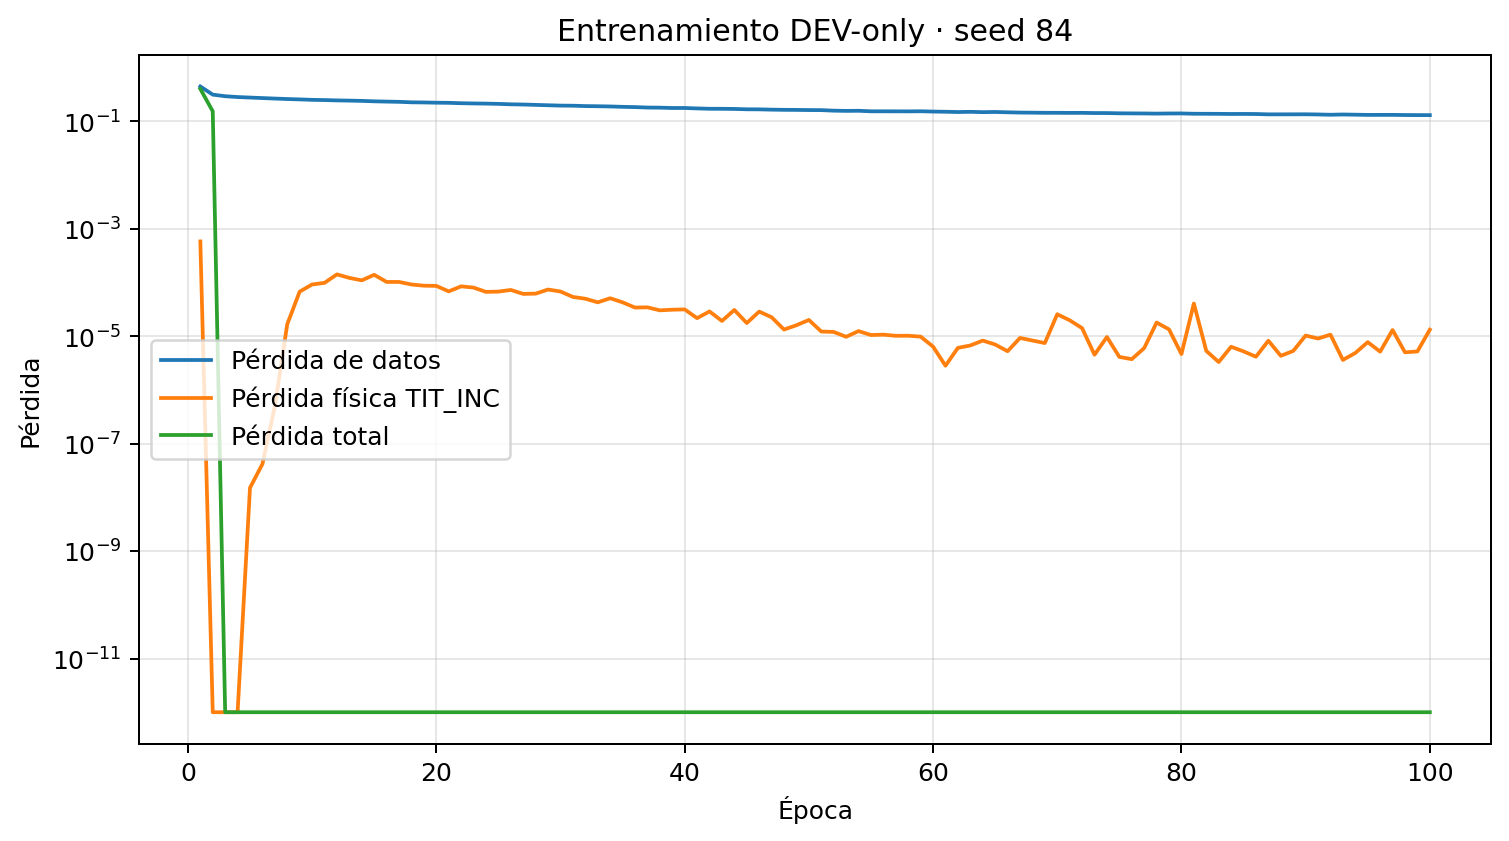

### FINAL-02_dev_parity

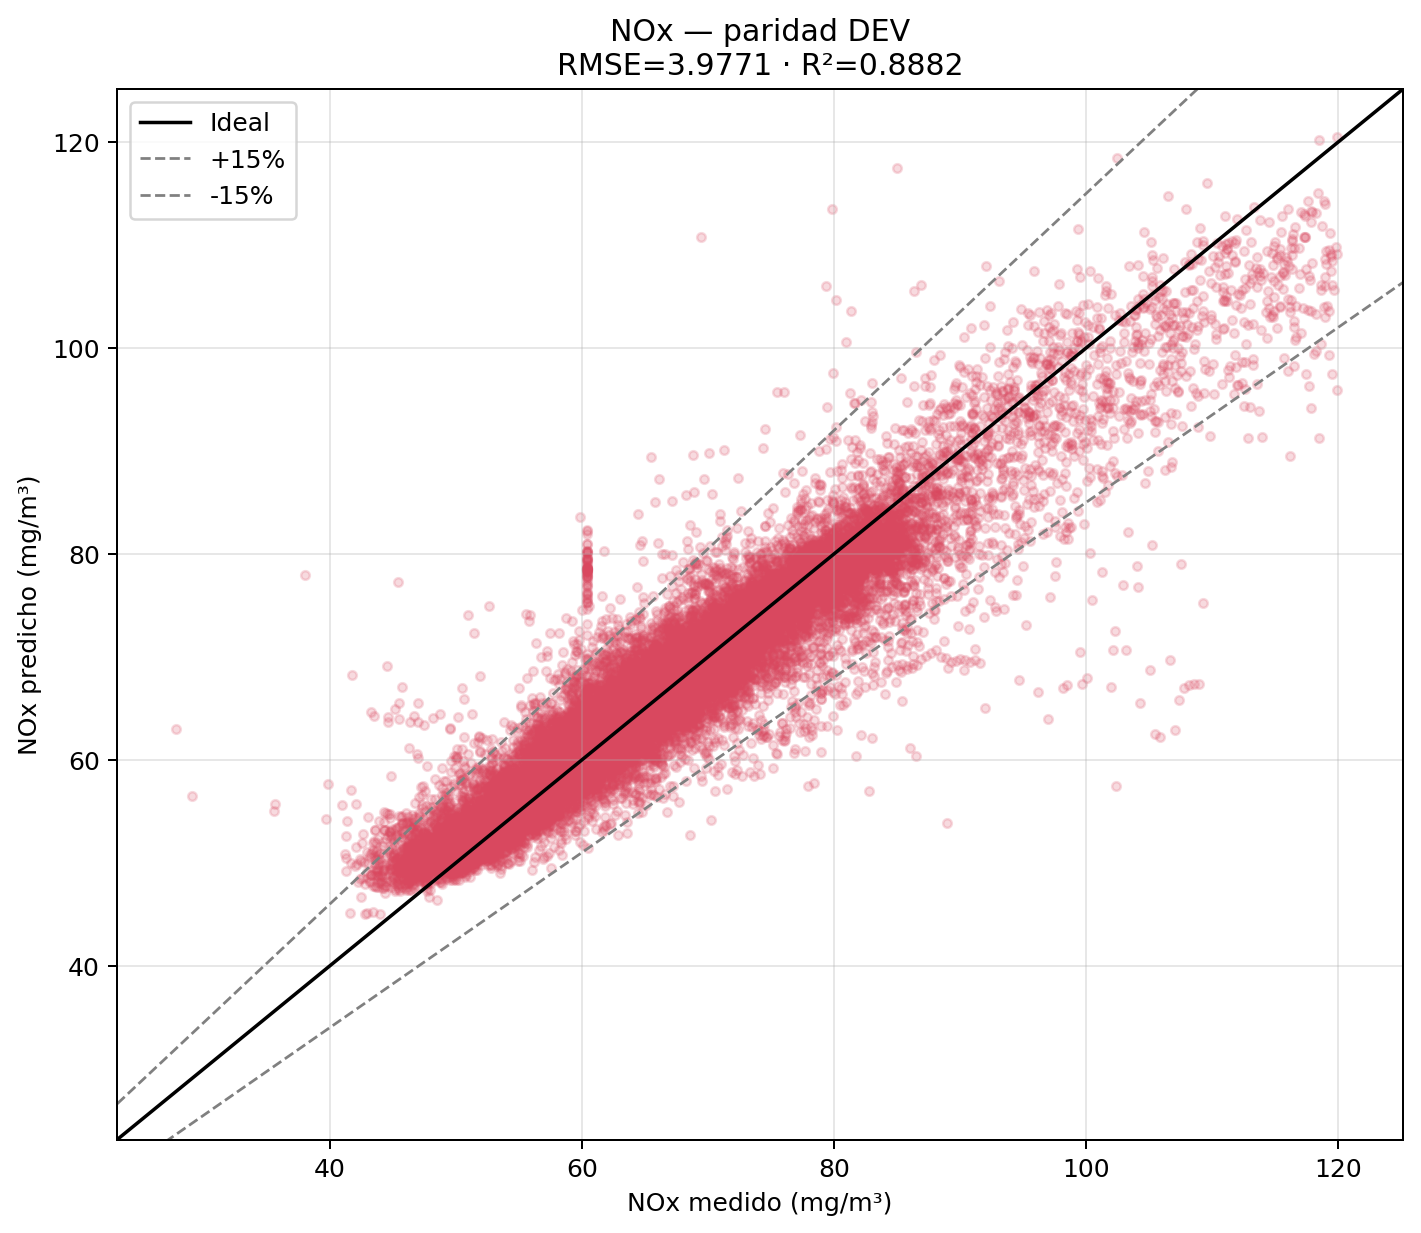

### FINAL-03_test_parity

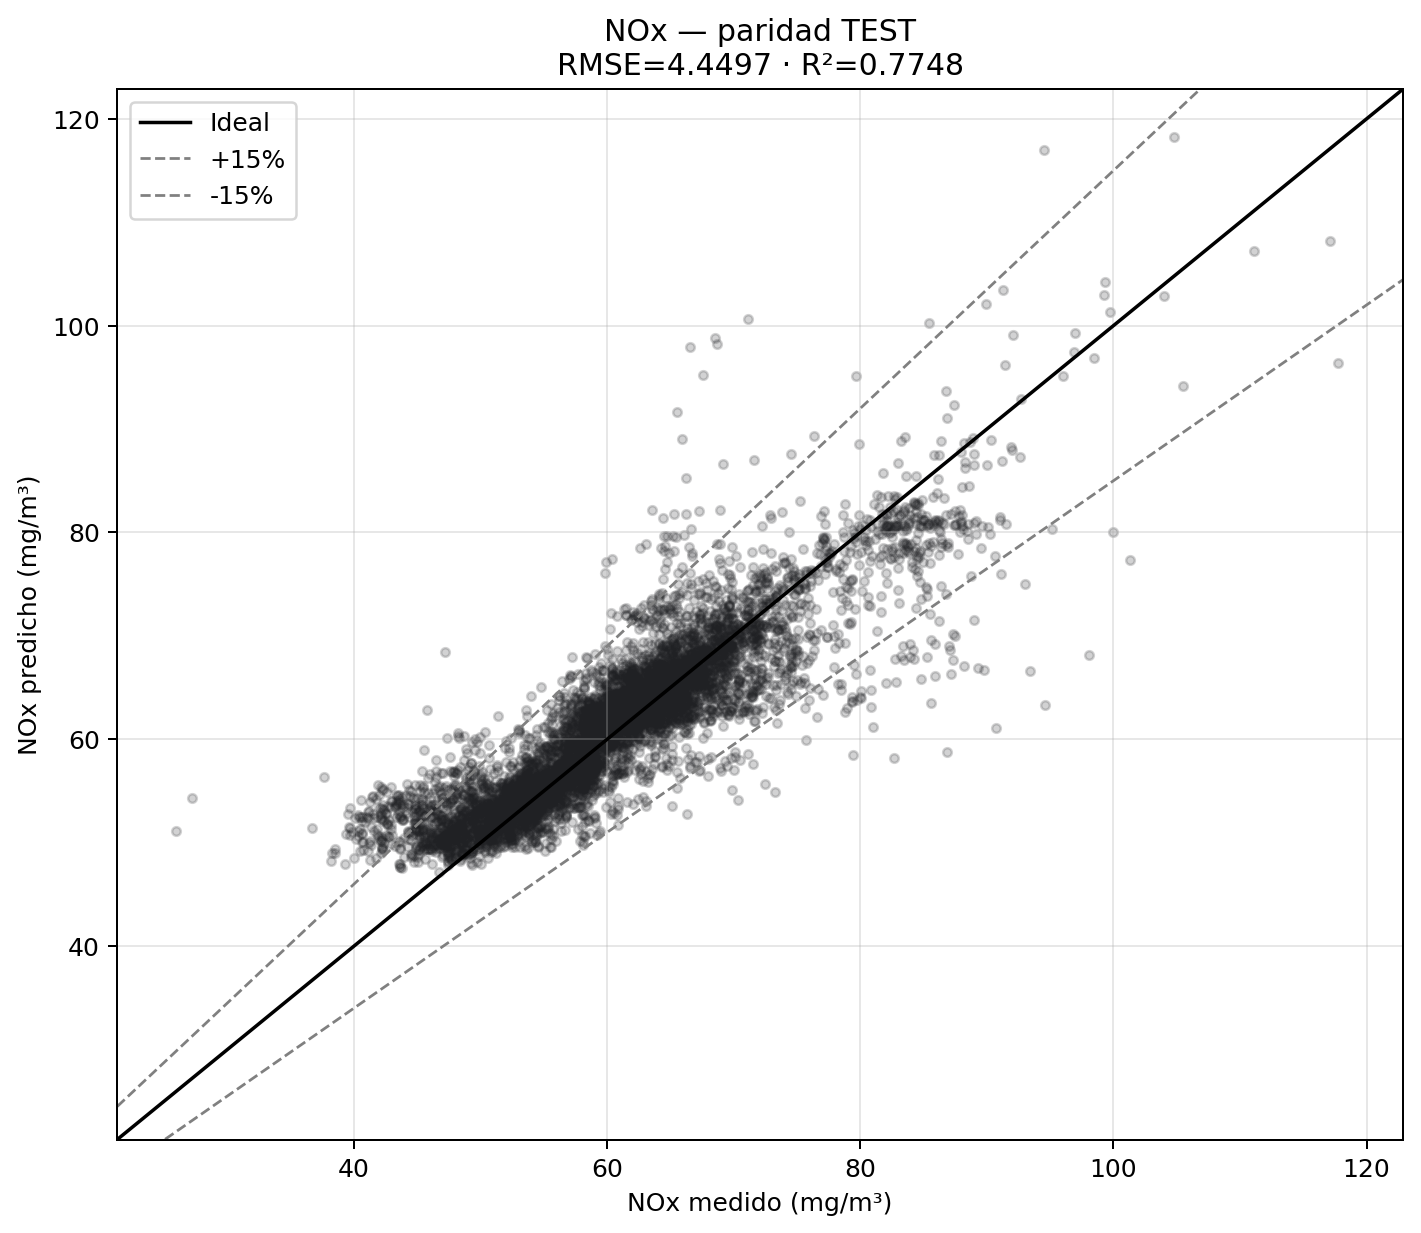

### FINAL-04_test_residual_vs_predicted

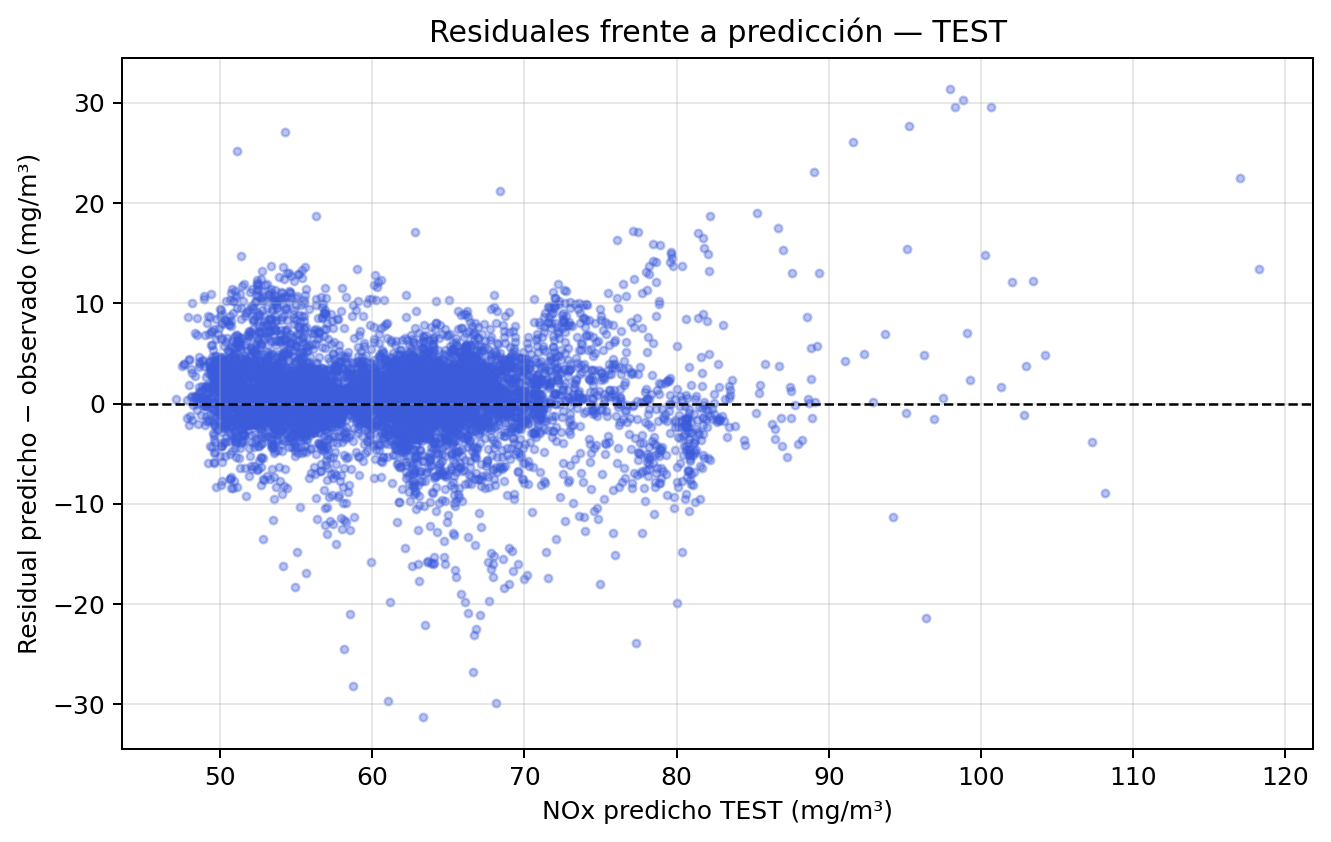

### FINAL-05_test_residual_distribution

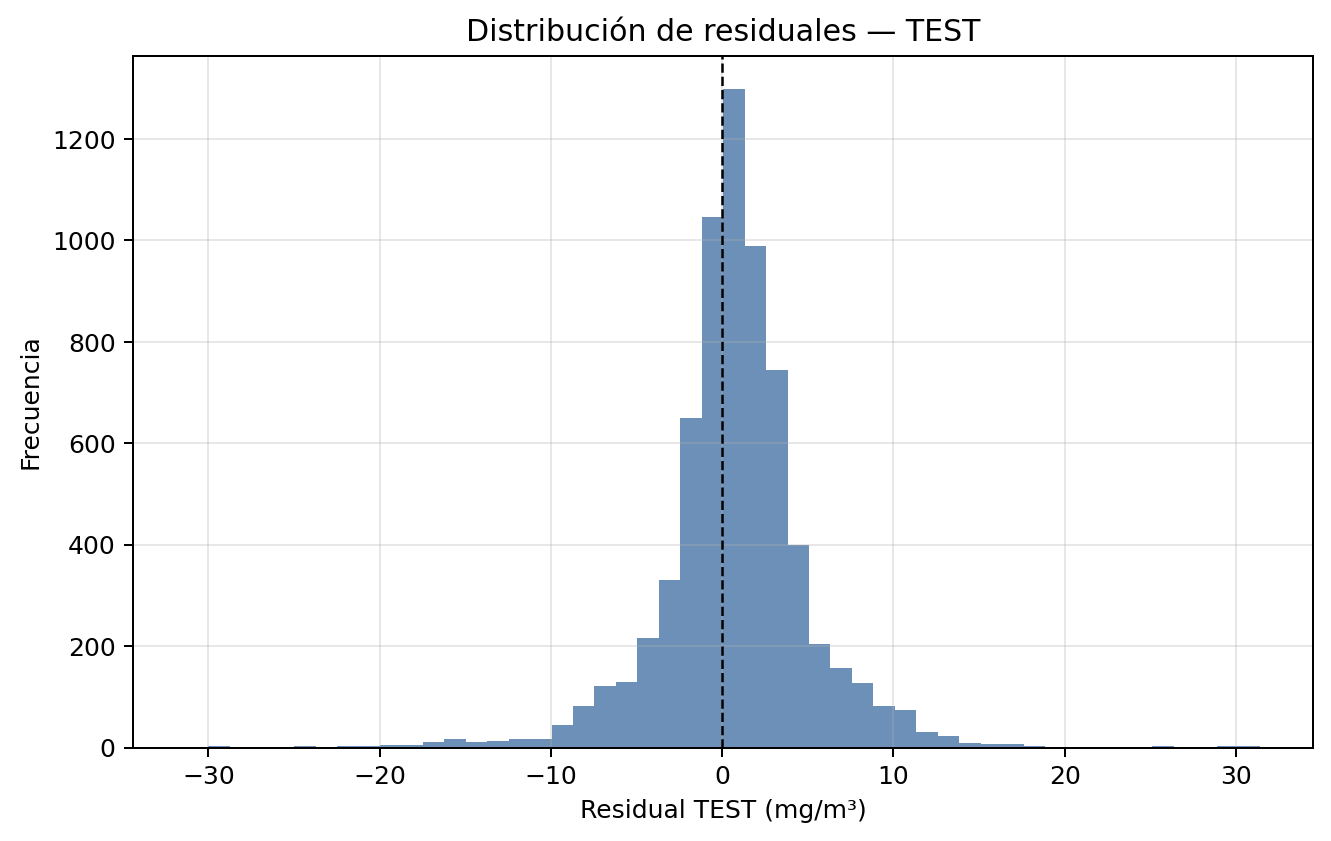

### FINAL-06_physical_gradient_distribution

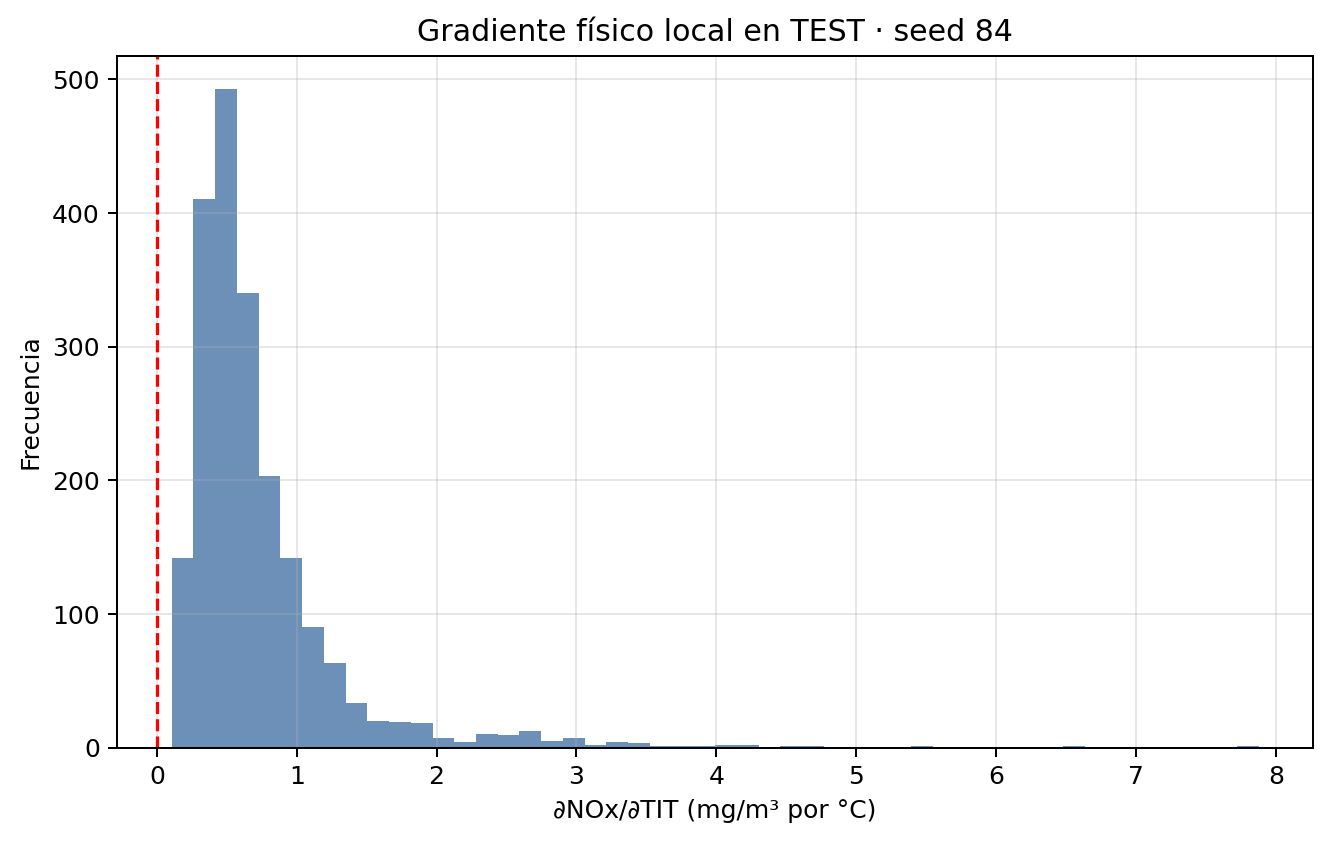

### FINAL-07_physical_PDP_TIT

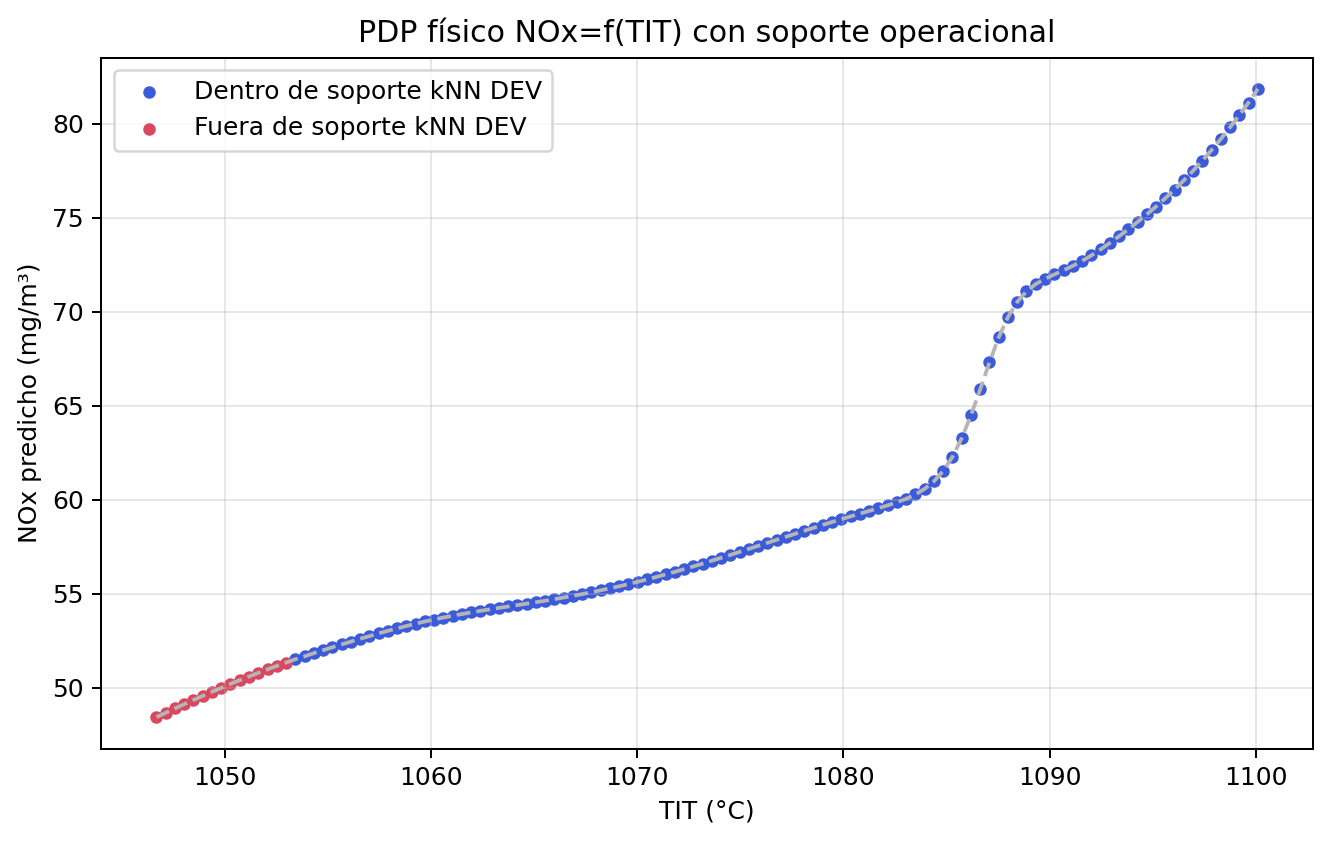

### FINAL-08_computational_profile

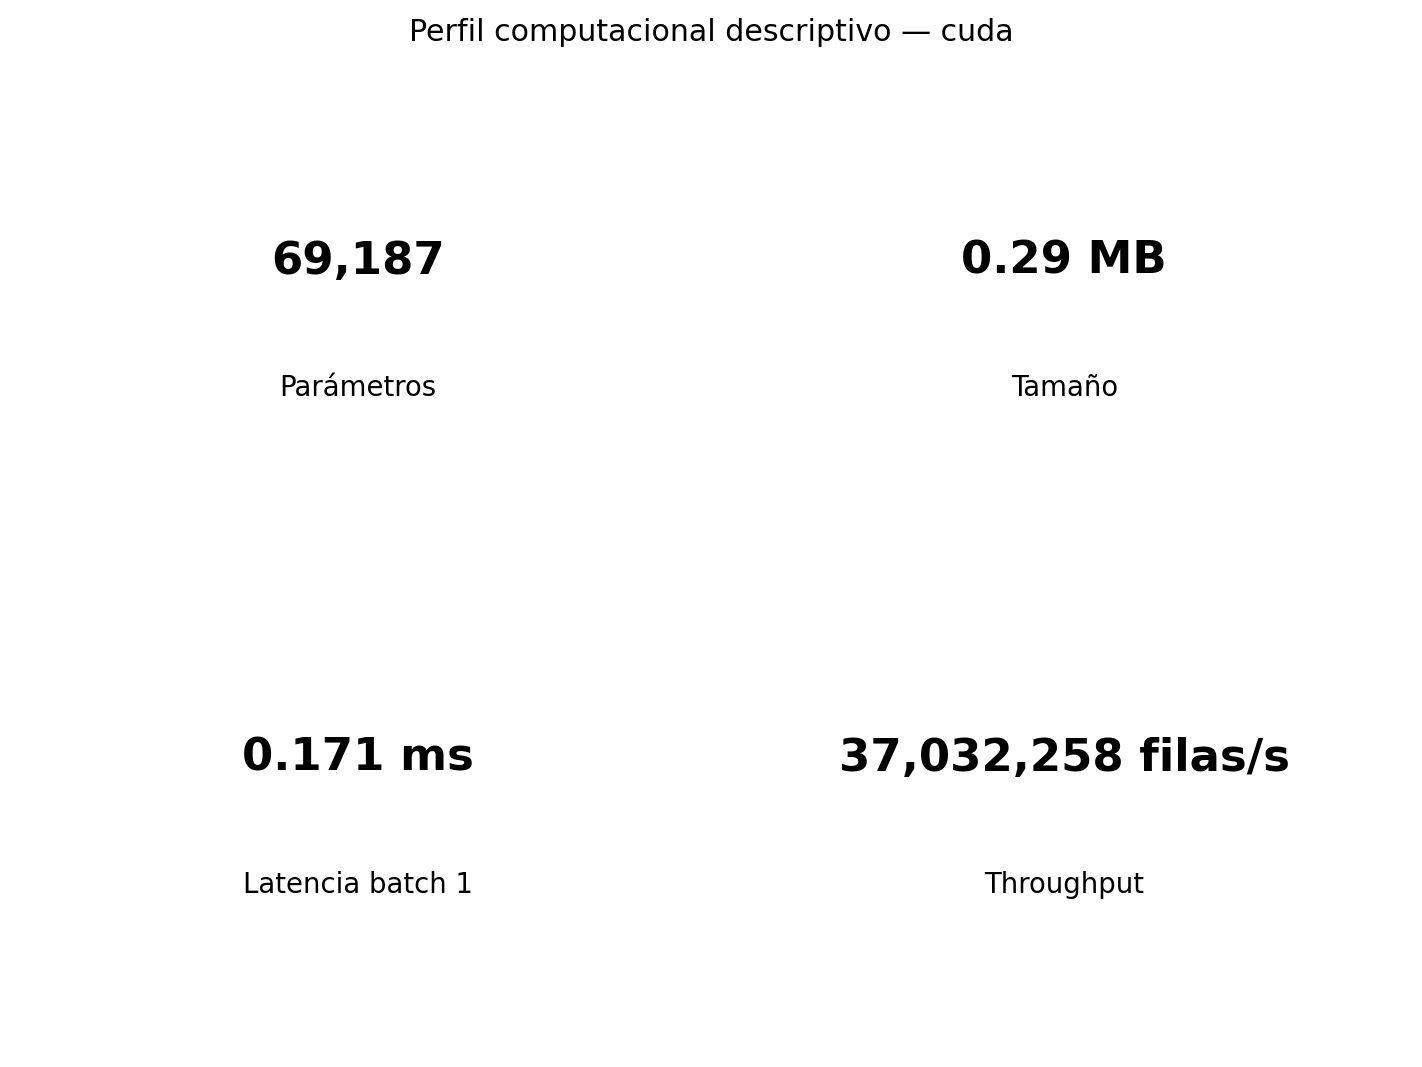

### FINAL-09_combined_parity_dev_test

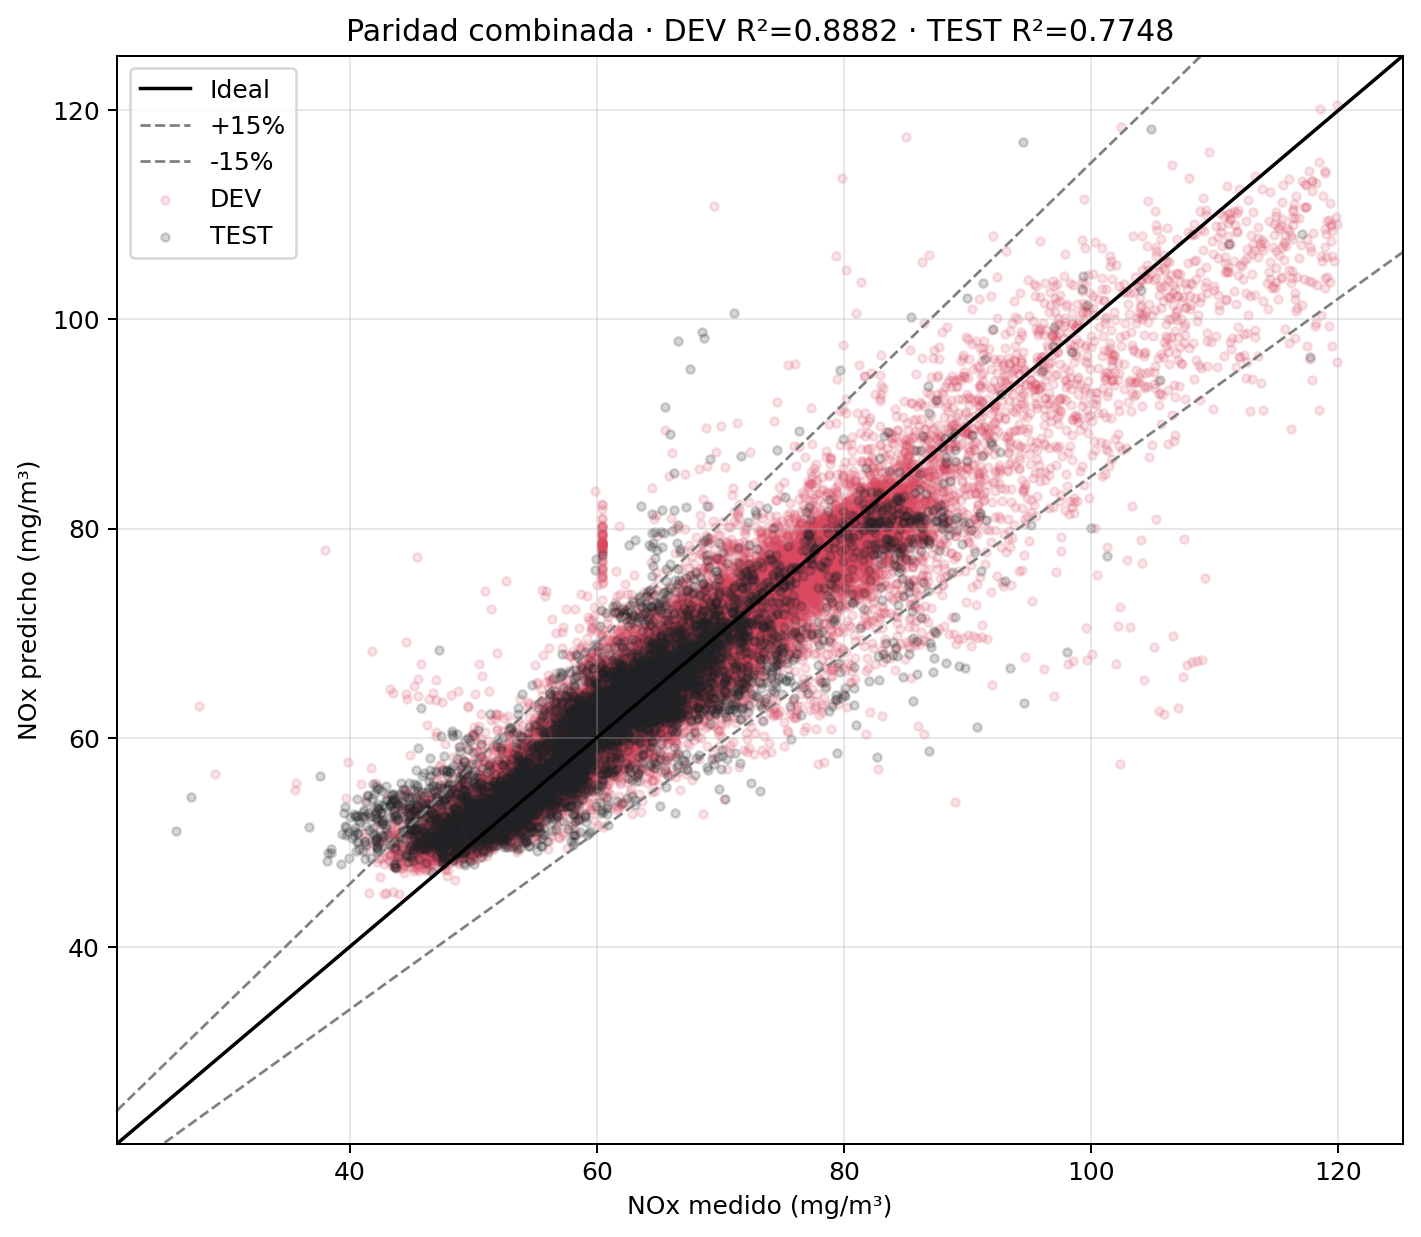

### FINAL-10_dev_operational_series

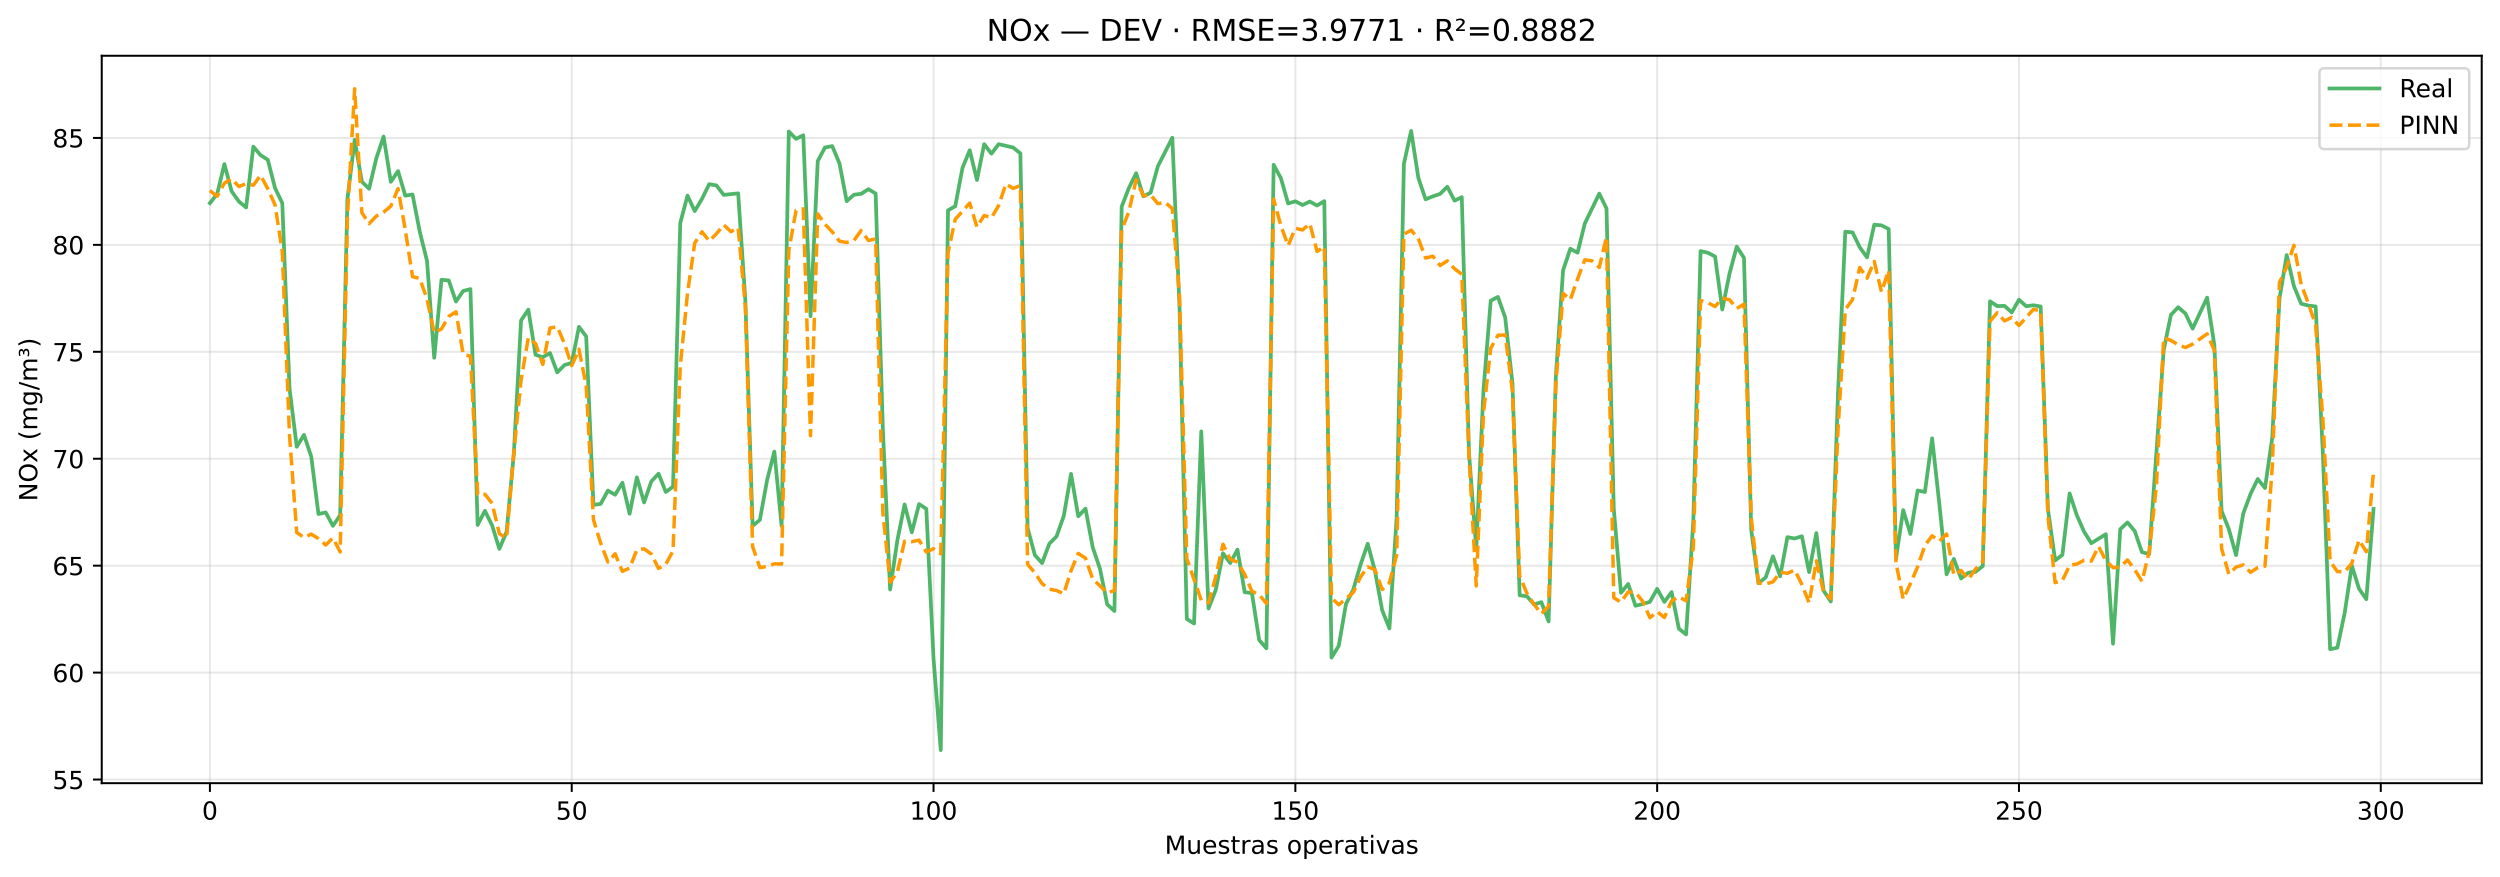

### FINAL-11_test_operational_series

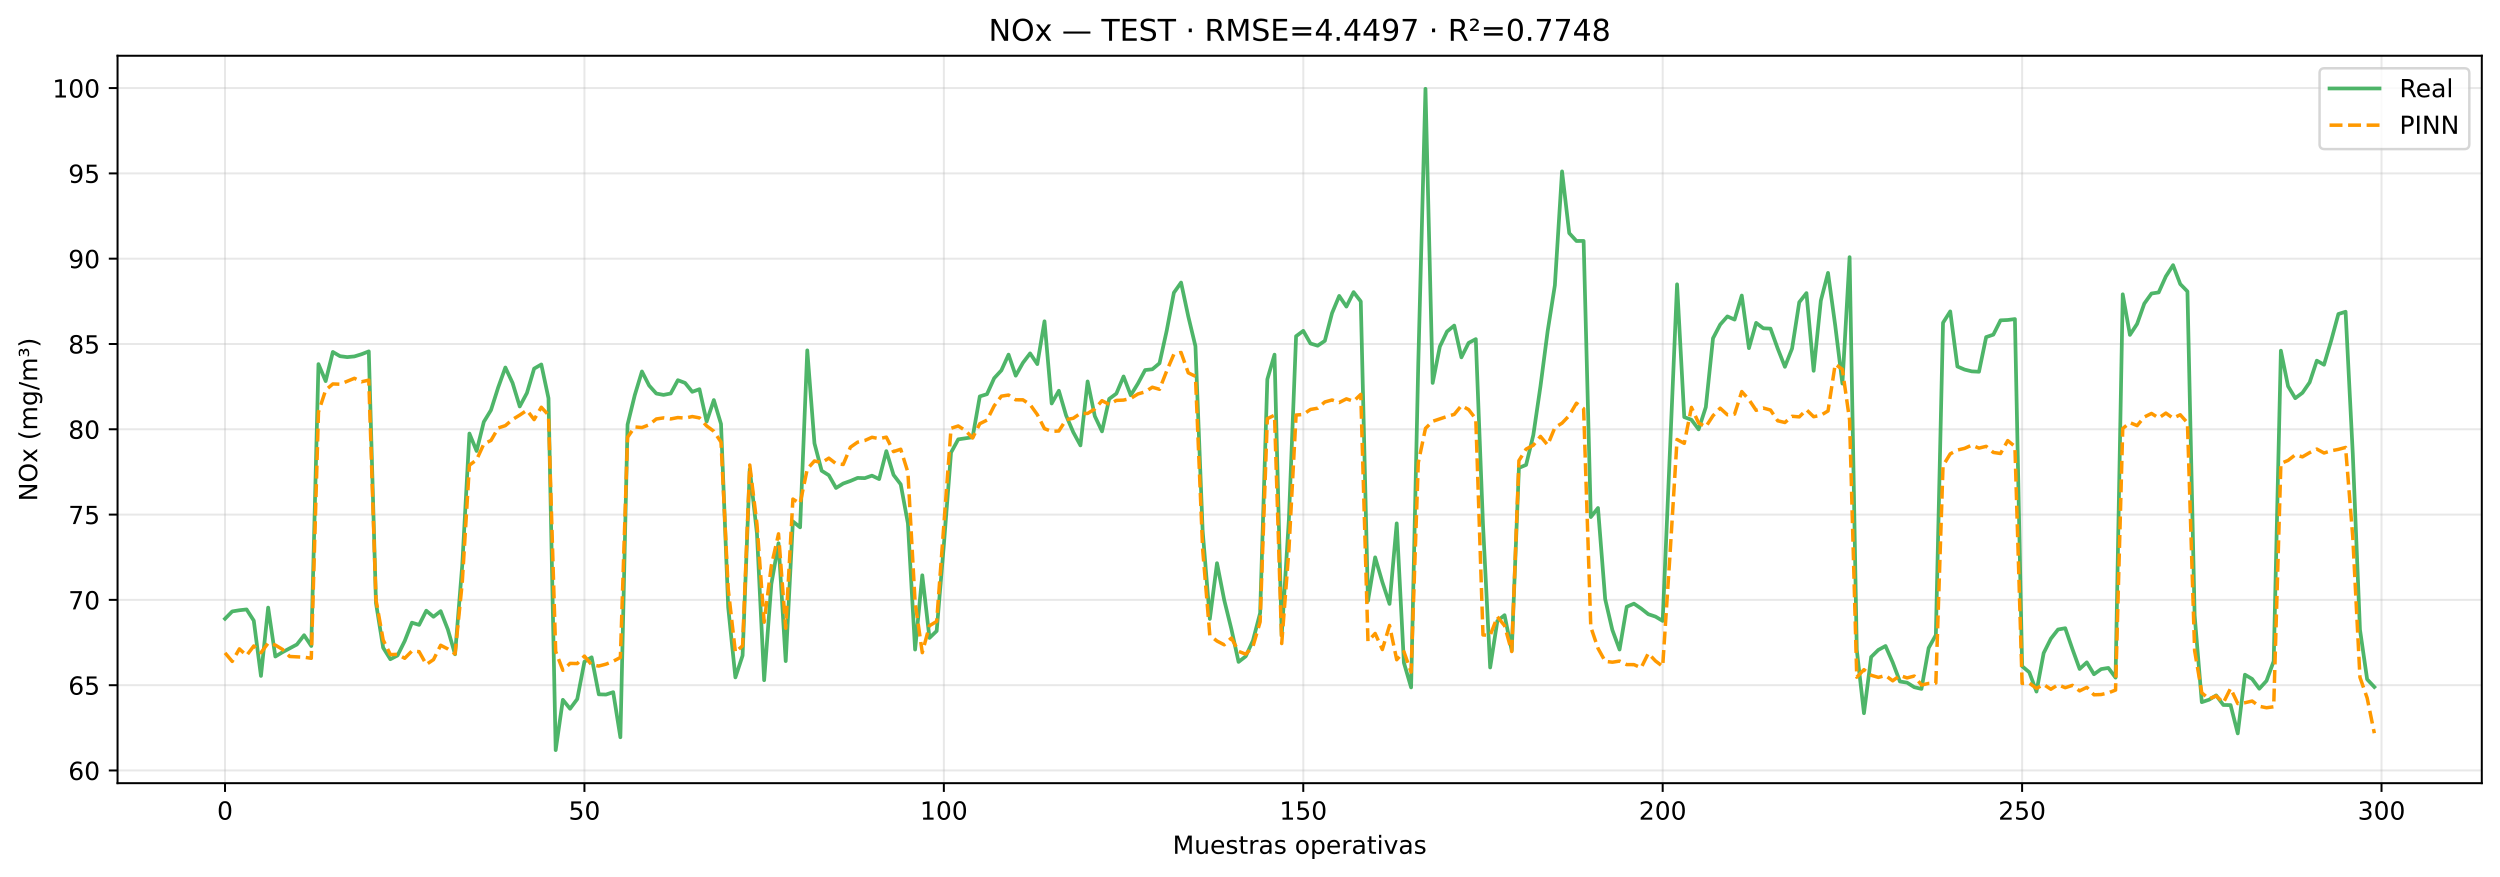

### FINAL-12_test_residual_vs_CDP

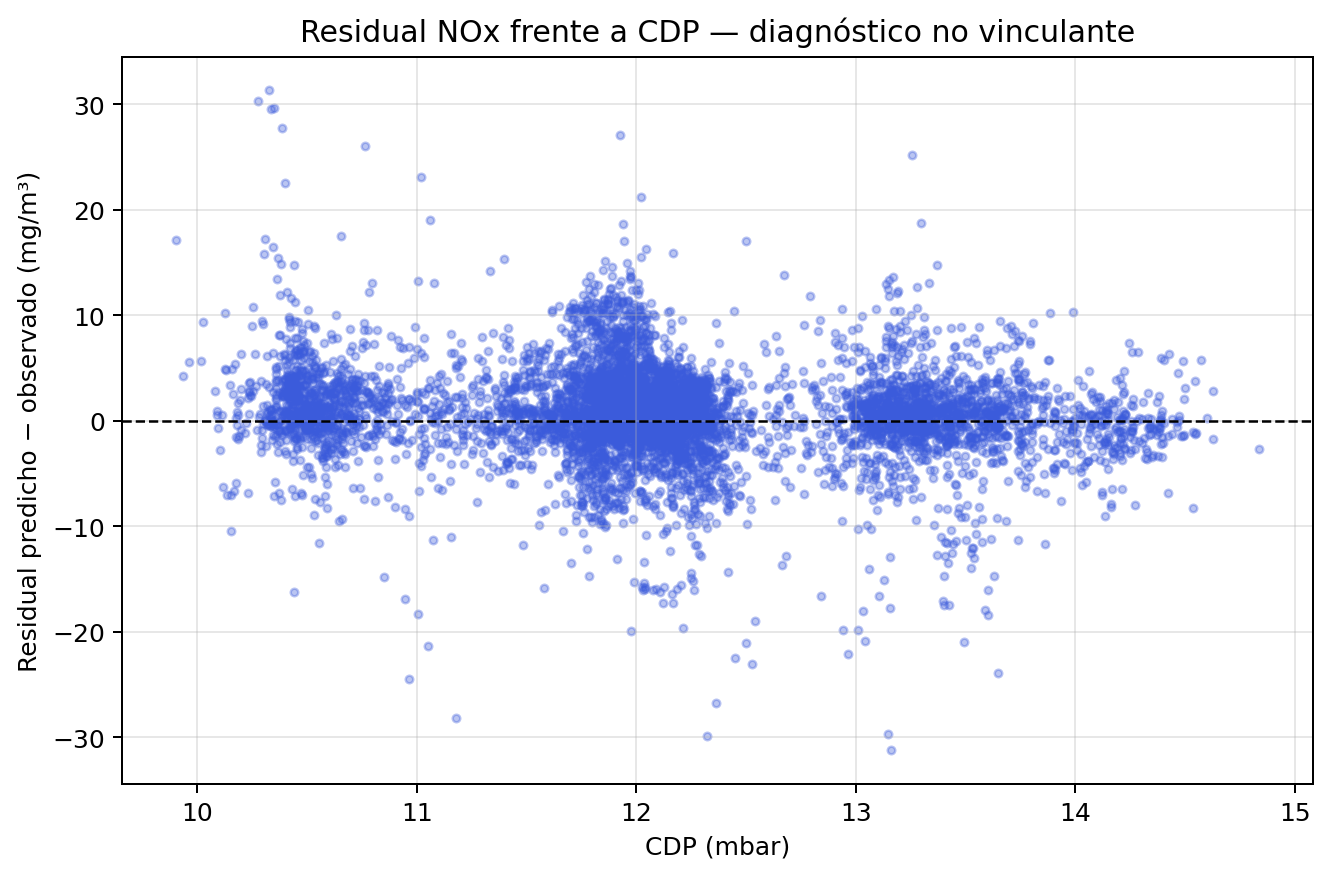

### FINAL-13_test_residual_diagnostics

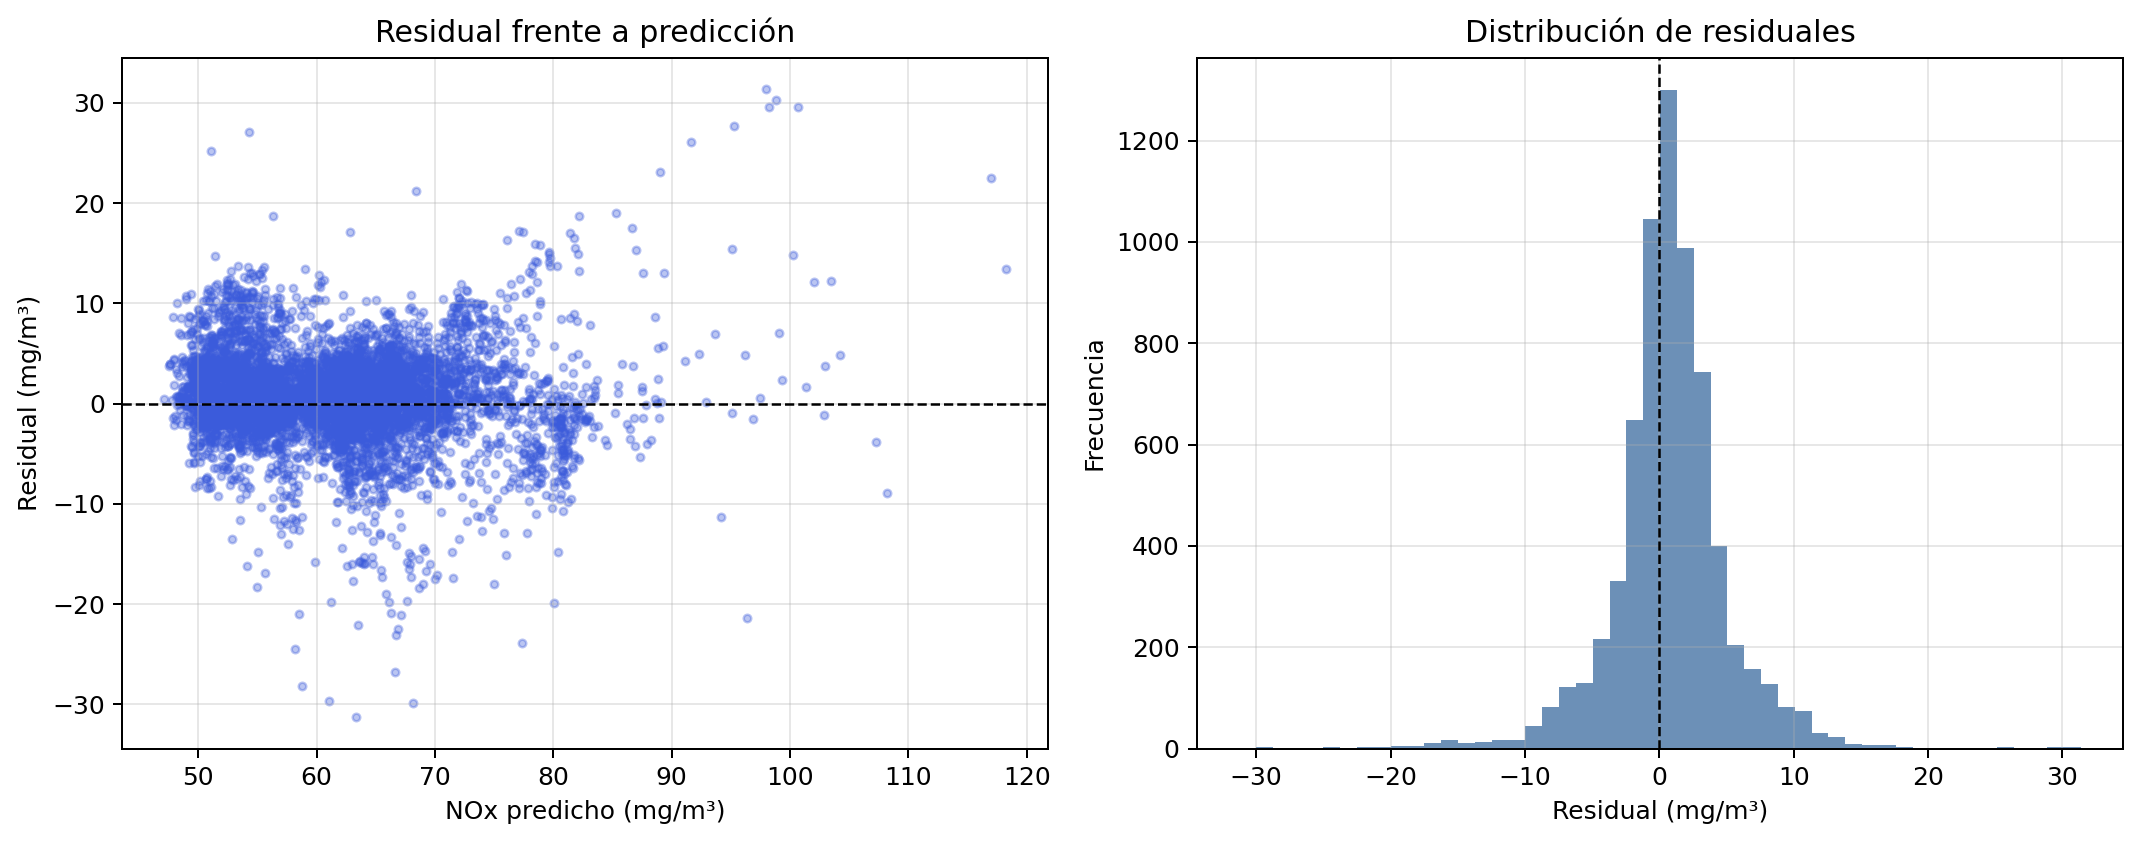

In [21]:
# [POST-RUN VIEW] Figuras finales incrustadas
from pathlib import Path
from IPython.display import Image, Markdown, display

figure_dir = Path(r"C:\ChatGPT-Work\Walk_Forward R8\models\interp\work_pinn_nox_interp_final_r6f_std\figures")
for figure_path in sorted(figure_dir.glob("FINAL-*.png")):
    display(Markdown(f"### {figure_path.stem}"))
    display(Image(filename=str(figure_path)))